In [1]:
# 1.1)
import os
import pickle
import datetime
from collections import defaultdict

In [2]:
# 1.2)
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import sklearn as skl
import pandas as pd
#import dill
import json
import copy

In [3]:
# 1.3)
import torch
import torch.optim as optim
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms import ToTensor, Lambda, Compose
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
#from torchviz import make_dot

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## **Ejercicio 2)**

Bajando y Jugando con el dataset **Fashion-MNIST**.

**1)** Baje y transforme los conjuntos de entrenamiento y testeo de FashionMNIST.

**2)** Grafique un mosaico de 3x3 imagenes de FashionMNIST, cada una titulada con su respectiva clasificación

In [5]:
# 2.1)
# Define a transform to normalize the data between [0,1]
transform = transforms.Compose([transforms.ToTensor()])

# Download and load the training data
train_set_orig = datasets.FashionMNIST('MNIST_data/', download = True, train = True,  transform = transform)
valid_set_orig = datasets.FashionMNIST('MNIST_data/', download = True, train = False, transform = transform)

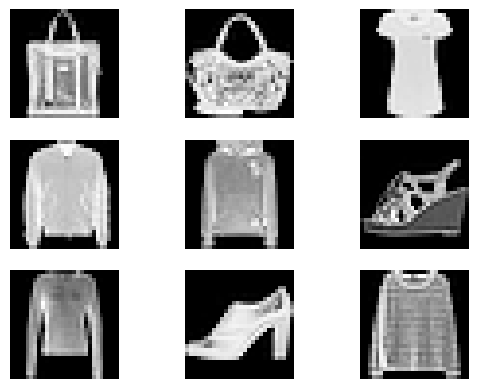

In [6]:
# 2.2)
figure = plt.figure()
cols,rows = 3,3
for i in range(1,cols*rows+1):
    j = torch.randint(len(train_set_orig),size=(1,)).item() # Los números aleatorios tambien se pueden generar desde pytorch. Util para trabajar en la GPU.
    image,label = train_set_orig[j]
    figure.add_subplot(rows,cols,i)
    #plt.title(labels_names[label])
    plt.axis("off")
    plt.imshow(image.squeeze(),cmap="Greys_r")
plt.show()

## Ejercicio 3) Creando un `DataSet` personalizado.

**1)** Con el fin de implementar un autoencoder, cree una clase derivada de la clase `DataSet` (llámela, por ejemplo `CustomDataset`) que, en vez de retornal el label asociado a cada imagen de `FashionMNIST`, retorne la imagen misma.

**2)** Utilice dicha clase para transformar los conjuntos de entrenamiento y testeo de `FashionMNIST` pensados para clasificación, a correspondientes conjuntos pensados para entrenar un autoencoder.
Para ello, defina una clase `CustomDataset` que deriva de la clase `Dataset`, cuyo método `__getitem__(self,i)` retorne el pair `input,output` donde tanto `input` cómo `output` son iguales a la $i$-ésima imagen del dataset.

In [7]:
# 3.1)
# Creamos una subclase de la clase Dataset que nos sirva para generar lotes de ejemplos que puedan usarse para entrenar un autoencoder
class CustomDataset(Dataset):
    def __init__(self,dataset):
        self.dataset=dataset
    # Redefinimos el método .__len__()
    def __len__(self):
        return len(self.dataset)
    # Redefinimos el método .__getitem__()
    def __getitem__(self,i):
        image,label=self.dataset[i]
        entrada  = image
        salida = image #torch.flatten(image) # retornamos la imagen como salida
        return entrada,salida

In [8]:
# 3.2)
# Convertimos FashionMNIST Dataset a CustomDataset
train_set = CustomDataset(train_set_orig)
test_set = CustomDataset(valid_set_orig)

## Ejercicio 4) Red Neuronal Autoencoder Convolucional

**1)** Defina y cree una red neuronal *autoencoder convolucional* constituida por las siguientes capas:


1. Capa convolucional 2D (encoder) compuesta por:

  * Una capa `Conv2d` (ver [documentación](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)) que mapea una entrada con $1$ canal y dimensiones $(28,28)$ a una salida con $16$ canales y dimensiones $(26,26)$.
    Utilice un kernel de dimensiones $(3,3)$ y el resto de los parámetros en sus valores por defecto.
  * Una capa `ReLU`.
  * Una capa `MaxPool2d` con un kernel de dimensiones $(2,2)$, de modo que la salida resultante tenga dimensiones $(16,13,13)$.
  * Una capa `Dropout` con probabilidad $p$.

2. Capa lineal (cuello de botella o “bottleneck”) compuesta por:

  * Una capa `Flatten` que transforma una entrada de dimensiones $(16,13,13)$ en un vector de dimensión $16\times 13\times 13 = 2704$.
  * Una capa `Linear` que mapea el vector de dimensión $2704$ a un vector de dimensión $n$ (donde $n$ es un número mucho menor, por ejemplo $n=128$, representando la *codificación comprimida* o *latente*).
  * Una capa `ReLU`.
  * Una capa `Linear` que mapea de nuevo el vector de dimensión $n$ al espacio original de dimensión $2704$.
  * Una capa `ReLU`.

3. Capa convolucional 2D transpuesta (decoder) compuesta por:

  * Una capa `Unflatten` que mapea el vector de dimensión $2704$ a una representación de $16$ canales con dimensiones $(13,13)$.
  * Una capa `ConvTranspose2d` (ver [documentación](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html)) que mapea $16$ canales de dimensiones $(13,13)$ a $1$ canal de dimensiones $(28,28)$. Utilice un kernel de dimensiones $(6,6)$, un stride de $(2,2)$, y un padding de $(1,1)$.
  * Una capa `Sigmoid`, para asegurar que las salidas se encuentren en el rango $[0,1]$ (asumiendo que las imágenes originales también fueron normalizadas en dicho rango).

**2)** Grafique, a modo de comparación, algunas imágenes de entrada y sus correspondientes reconstrucciones obtenidas con el modelo **sin entrenar** y con una probabilidad de *dropout* $p=0.2$.

In [9]:
# 4.1)
class AutoEncoder(nn.Module):
    def __init__(self, drop_out, latent_dim=28*28):
        super(AutoEncoder, self).__init__()
        
        # ---------- ENCODER ----------
        self.encoder = nn.Sequential(
            # First Convolutional layer
            nn.Conv2d(1, 16, kernel_size=3, padding=1),   # 16 × 28 × 28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 16 × 14 × 14
            nn.Dropout(drop_out),
            
            # Second Convolutional layer
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # 32 × 14 × 14
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 32 × 7 × 7

            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim), #32*7*7
            nn.ReLU(),
            nn.Dropout(drop_out)
        )
        
        # ---------- DECODER ----------
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),

            # 7x7 -> 14x14
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),

            # 14x14 -> 28x28
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [74]:
def train(dataloader, my_model, loss_function, optimizer):
    my_model.train()
    num_samples = len(dataloader.dataset)
    num_batches = len(dataloader)
    sum_batch_avg_loss = 0
    batch_avg_loss = 0
    num_processed_samples = 0
    avg_loss = 0
    sum_correct = 0
    
    my_model = my_model.to(device)
    
    for batch, (X,X_target) in enumerate(dataloader):
        X_train = X.to(device)
        X_target = X_target.to(device)
        batch_size = len(X_train)
        num_processed_samples += batch_size
        
        x_hat = my_model(X)
        loss = loss_function(x_hat, X_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_avg_loss = loss.item()
        sum_batch_avg_loss += batch_avg_loss
    avg_loss = sum_batch_avg_loss/num_batches
    return avg_loss

In [11]:
def test(dataloader, my_model, loss_function):
    # Entramos en modo testeo, al igual que en modo train, se restringen algunas funciones.
    my_model.eval()
    num_samples = len(dataloader.dataset)
    num_batches = len(dataloader)
    sum_batch_avg_loss = 0
    num_processed_samples = 0
    batch_avg_loss = 0
    batch_size = 0
    sum_correct = 0
    avg_loss = 0
    my_model = my_model.to(device)
    # Desactivamos el calculo de gradiente:
    with torch.no_grad():
        for X, X_target in test_loader:
            X.to(device)
            X_target.to(device)
            batch_size = len(X)
            num_processed_samples += batch_size
            # Predecimos con nuestro modelo
            x_hat = my_model(X)
            # Calculamos el error:
            loss = loss_function(x_hat, X_target)
            batch_avg_loss = loss.item() 
            sum_batch_avg_loss += batch_avg_loss
            
                       
    avg_loss = sum_batch_avg_loss/num_batches
    return avg_loss

In [12]:
# Create train and test set:
batch_size = 20
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

train_batches_count = len(train_loader)
test_batches_count = len(test_loader)
print(f"Cantidad de batches en train: {train_batches_count}")
print(f"Cantidad de batches en test: {test_batches_count}")

Cantidad de batches en train: 3000
Cantidad de batches en test: 500


In [13]:
# Loss function for our AutoEnconder:
loss_function = nn.MSELoss() # Medium Squared Error 

In [14]:
# Create our model:
AutoEncoder_model = AutoEncoder(drop_out=0.2)

### Veamos nuestras arquitecturas:

In [15]:
AutoEncoder_model.encoder

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Dropout(p=0.2, inplace=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Flatten(start_dim=1, end_dim=-1)
  (8): Linear(in_features=1568, out_features=784, bias=True)
  (9): ReLU()
  (10): Dropout(p=0.2, inplace=False)
)

In [16]:
AutoEncoder_model.decoder

Sequential(
  (0): Linear(in_features=784, out_features=1568, bias=True)
  (1): Unflatten(dim=1, unflattened_size=(32, 7, 7))
  (2): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
  (3): ReLU()
  (4): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
  (5): Sigmoid()
)

#### Esto nos asegura que estemos creando bien el modelo.

In [17]:
# Optimizer for our AutoEnconder:
lr = 0.001
AE_optimizer = torch.optim.Adam(params=AutoEncoder_model.parameters(), lr=lr)

In [18]:
# Send the model to our device:
AutoEncoder_model = AutoEncoder_model.to(device)

In [19]:
# Train and test our AutoEnconder:
def train_test(train_loader, test_loader, AutoEncoder_model, AE_optimizer, loss_function, epochs):
    epochs = epochs
    list_train_avg_loss = []
    list_test_avg_loss = []
    list_train_accuracy = []
    list_test_accuracy = []
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n------------------------------")
        train_avg_loss_inc = train(train_loader,
                                         AutoEncoder_model,
                                         loss_function,
                                         AE_optimizer)
        train_avg_loss = test(train_loader,
                                AutoEncoder_model,
                                loss_function)

        test_avg_loss = test(test_loader,
                                    AutoEncoder_model,
                                    loss_function)

        list_train_avg_loss.append(train_avg_loss)
        list_test_avg_loss.append(test_avg_loss)
        
    return(list_train_avg_loss, list_test_avg_loss)

# <center><u> Hagamos un ajuste de hiperparametros para nuestro auto enconder </center></u>

### Le agreguemos una capa mas convolucional:

In [15]:
AutoEncoder_model.encoder

NameError: name 'AutoEncoder_model' is not defined

In [ ]:
AutoEncoder_model.decoder

In [ ]:
avg_train_loss = []
avg_test_loss = []
avg_train_loss, avg_test_loss = train_test(train_loader, test_loader, AutoEncoder_model,
                                                     AE_optimizer, loss_function)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

ax.plot(range(1, len(avg_train_loss)+1), avg_train_loss,
        label='train', linestyle='-.', c='green')

ax.plot(range(1, len(avg_test_loss)+1), avg_test_loss,
        label='test', linestyle='--', c='blue')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
avg_train_loss

In [ ]:
avg_test_loss

### Probemos con distintos tipos de dropout


🔹 Entrenando con dropout = 0.2
Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
[0.0017840831127638617, 0.0015295102006445329, 0.0014204562838810186, 0.0013399553179430466, 0.0012799658224297067, 0.0012378811247957249, 0.0011953152008354665, 0.0011889869297

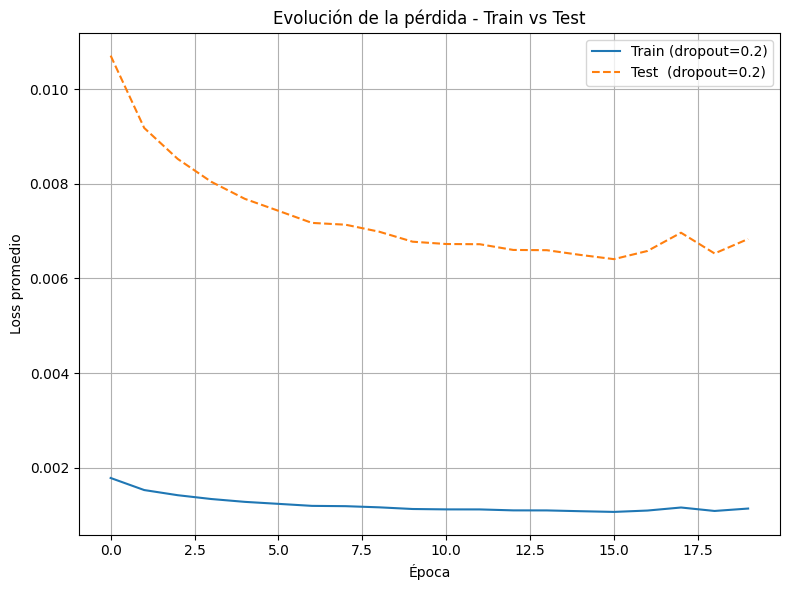

In [45]:
dropout_list = [0.2]#, 0.5, 0.7, 0.9]
epochs = 20
lr = 0.001

# Diccionarios para guardar resultados
results = {}

# ------------------------------------------------------
# BUCLE PRINCIPAL: probar varios learning rates
# ------------------------------------------------------
for dropout in dropout_list:
    print(f"\n🔹 Entrenando con dropout = {dropout}")
    # Crear modelo NUEVO para cada experimento
    AutoEncoder_model = AutoEncoder(drop_out=dropout).to(device)

    AE_optimizer = torch.optim.Adam(params=AutoEncoder_model.parameters(), lr=lr)

    # Entrenar y testear
    train_loss, test_loss = train_test(train_loader, test_loader, AutoEncoder_model,
                                                     AE_optimizer, loss_function, epochs)

    # Guardar resultados
    results[dropout] = {
        "train_loss": train_loss,
        "test_loss": test_loss
    }


plt.figure(figsize=(8,6))

for dropout, data in results.items():
    print(data["train_loss"])
    print(data["test_loss"])
    plt.plot(data["train_loss"], label=f"Train (dropout={dropout})", linestyle='-')
    plt.plot(data["test_loss"],  label=f"Test  (dropout={dropout})", linestyle='--')

plt.title("Evolución de la pérdida - Train vs Test")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Cambiemos nuestros tamanios de batches:

In [20]:
batch_list = [20 ,64, 100, 200]
epochs = 20
lr = 0.0001
dropout = 0.2
# Diccionarios para guardar resultados
results = {}

# ------------------------------------------------------
# BUCLE PRINCIPAL: probar varios learning rates
# ------------------------------------------------------
for batch in batch_list:
    print(f"\n🔹 Entrenando con batch = {batch}")
    # Crear modelo NUEVO para cada experimento
    AutoEncoder_model = AutoEncoder(drop_out=dropout).to(device)
    train_loader = DataLoader(train_set, batch_size=batch, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch, shuffle=True)

    AE_optimizer = torch.optim.Adam(params=AutoEncoder_model.parameters(), lr=lr)

    # Entrenar y testear
    train_loss, test_loss = train_test(train_loader, test_loader, AutoEncoder_model,
                                                     AE_optimizer, loss_function, epochs)

    # Guardar resultados
    results[batch] = {
        "train_loss": train_loss,
        "test_loss": test_loss
    }


plt.figure(figsize=(8,6))

for batch, data in results.items():
    print(data["train_loss"])
    print(data["test_loss"])
    plt.plot(data["train_loss"], label=f"Train (batch={batch})", linestyle='-')
    plt.plot(data["test_loss"],  label=f"Test  (batch={batch})", linestyle='--')

plt.title("Evolución de la pérdida - Train vs Test")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🔹 Entrenando con batch = 20
Epoch 1
------------------------------


KeyboardInterrupt: 

### Cambiemos nuestro learning rate:


🔹 Entrenando con lr = 0.001
Epoch 1
------------------------------

🔹 Entrenando con lr = 0.0001
Epoch 1
------------------------------

🔹 Entrenando con lr = 1e-05
Epoch 1
------------------------------
[0.0020671330199887356]
[0.01240279813669622]
[0.002889903818567594]
[0.01733942289277911]
[0.007777052912861109]
[0.04666231764853001]


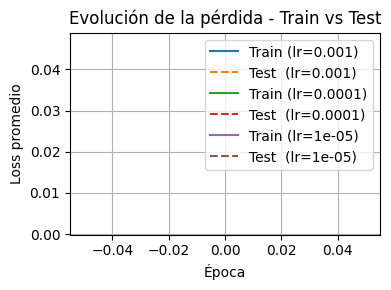

In [22]:
lr_list = [0.001, 0.0001, 0.00001]
epochs = 1

# Diccionarios para guardar resultados
results = {}

# ------------------------------------------------------
# BUCLE PRINCIPAL: probar varios learning rates
# ------------------------------------------------------
for lr in lr_list:
    print(f"\n🔹 Entrenando con lr = {lr}")
    # Crear modelo NUEVO para cada experimento
    AutoEncoder_model = AutoEncoder(drop_out=0.2).to(device)

    AE_optimizer = torch.optim.Adam(params=AutoEncoder_model.parameters(), lr=lr)

    # Entrenar y testear
    train_loss, test_loss = train_test(train_loader, test_loader, AutoEncoder_model,
                                                     AE_optimizer, loss_function, epochs)

    # Guardar resultados
    results[lr] = {
        "train_loss": train_loss,
        "test_loss": test_loss
    }


plt.figure(figsize=(4,3))

for lr, data in results.items():
    print(data["train_loss"])
    print(data["test_loss"])
    plt.plot(data["train_loss"], label=f"Train (lr={lr})", linestyle='-')
    plt.plot(data["test_loss"],  label=f"Test  (lr={lr})", linestyle='--')

plt.title("Evolución de la pérdida - Train vs Test")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

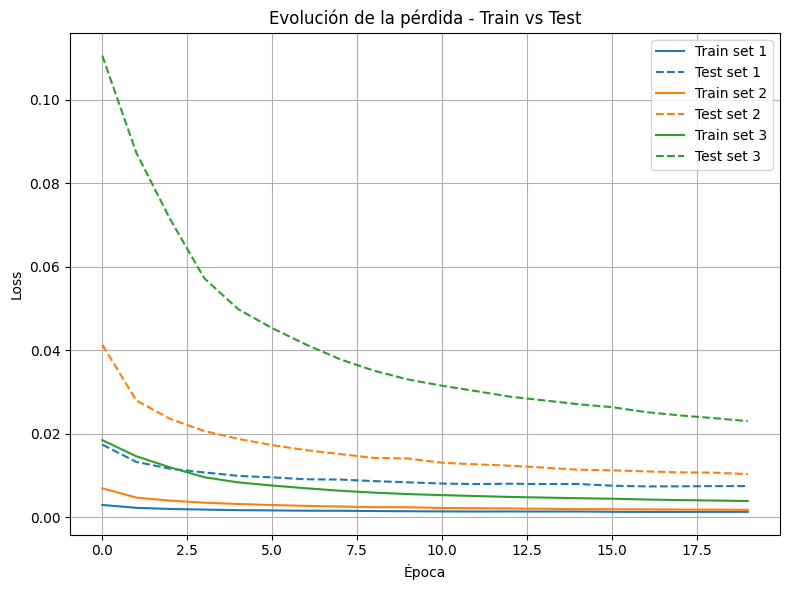

In [24]:
train1 = [0.002891940977424383, 0.0022009274022032816, 0.0019279932913680872, 0.001780058406293392, 0.001643412405004104, 0.0015837136997530858, 0.0015062329235176245, 0.0014960886382808288, 0.0014329964108765125, 0.0013857405337815484, 0.001337078867169718, 0.0013162641025458773, 0.0013301740447059273, 0.0013152567576617002, 0.001320236596899728, 0.0012497861574714381, 0.0012228596707185109, 0.0012244569944838684, 0.0012349242251366377, 0.0012352644000202418]
test1  = [0.017351645827293396, 0.013205564431846142, 0.011567959859967232, 0.010680350456386805, 0.009860474411398172, 0.009502282291650772, 0.009037397522479295, 0.008976531717926263, 0.008597978316247463, 0.008314443174749614, 0.008022473184391856, 0.007897584633901715, 0.007981044426560401, 0.007891540490090847, 0.007921419739723205, 0.007498716870322823, 0.007337158089503646, 0.007346741864457726, 0.007409545360133052, 0.007411586362868547]

train2 = [0.006881332856913408, 0.004654445555061102, 0.003917655125260353, 0.0034345977132519087, 0.0031200577815373737, 0.0028711239869395892, 0.002669507320970297, 0.002513386948655049, 0.002359527985875805, 0.0023357608479758103, 0.002167515205219388, 0.0021048399216185014, 0.002049273205921054, 0.00197470059307913, 0.001889019428441922, 0.0018643928784877063, 0.0018227942567318677, 0.0017821865777174631, 0.0017728545144200325, 0.0017114628696193299]
test2  = [0.04128799669444561, 0.027926673404872416, 0.02350593078881502, 0.020607586093246935, 0.018720346614718438, 0.01722674421966076, 0.01601704388856888, 0.015080321971327066, 0.014157167878001928, 0.014014565180987119, 0.013005091324448586, 0.012629039492458105, 0.012295639105141164, 0.01184820368885994, 0.011334116477519274, 0.011186357140541076, 0.010936765428632499, 0.010693119410425424, 0.010637127291411162, 0.01026877725496888]

train3 = [0.018424950018525125, 0.014552739262580872, 0.011886646325389544, 0.009537377754847209, 0.008300185799598694, 0.007543993977208932, 0.0068861578529079755, 0.006298773027956486, 0.005842720990379652, 0.005492099647720655, 0.005243487910677989, 0.005028232522308826, 0.004807327861587206, 0.004657296252747377, 0.0045062109890083475, 0.004387655388563871, 0.004191248640418053, 0.004058950698624055, 0.003949506226927042, 0.0038294072821736334]
test3  = [0.11054970160126686, 0.0873164364695549, 0.07131987854838372, 0.05722426727414131, 0.04980111420154572, 0.045263964235782626, 0.04131694756448269, 0.03779263861477375, 0.0350563258677721, 0.03295259777456522, 0.03146092772483826, 0.03016939464956522, 0.02884396765381098, 0.027943777553737163, 0.02703726578503847, 0.026325931958854198, 0.025147491730749608, 0.024353704452514648, 0.023697037436068057, 0.02297644380480051]

# -------------------------------------------------------------
# Graficar
# -------------------------------------------------------------
plt.figure(figsize=(8,6))

colors = ['tab:blue', 'tab:orange', 'tab:green']  # un color por set

# --- Set 1 ---
plt.plot(train1, label="Train set 1", linestyle='-',  color=colors[0])
plt.plot(test1,  label="Test set 1",  linestyle='--', color=colors[0])

# --- Set 2 ---
plt.plot(train2, label="Train set 2", linestyle='-',  color=colors[1])
plt.plot(test2,  label="Test set 2",  linestyle='--', color=colors[1])

# --- Set 3 ---
plt.plot(train3, label="Train set 3", linestyle='-',  color=colors[2])
plt.plot(test3,  label="Test set 3",  linestyle='--', color=colors[2])

plt.title("Evolución de la pérdida - Train vs Test")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

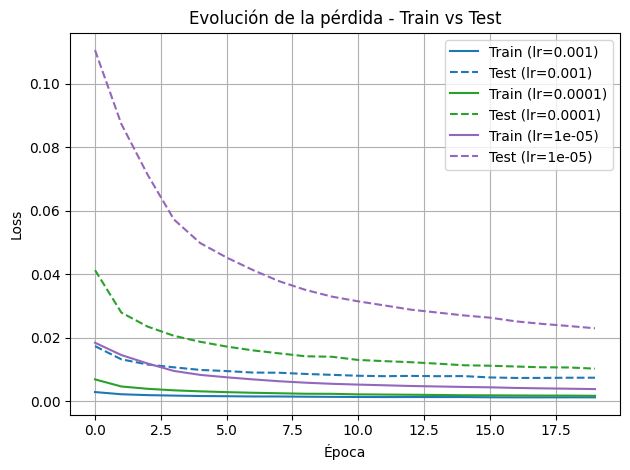

In [46]:
import matplotlib.pyplot as plt

# Learning rates correspondientes a cada set
lr1 = 0.001
lr2 = 0.0001
lr3 = 1e-5

colors = ['tab:blue', 'tab:green', 'tab:purple']

plt.figure(figsize=(8,6))

# --- Set 1 ---
plt.plot(train1, label=f"Train (lr={lr1})", linestyle='-',  color=colors[0])
plt.plot(test1,  label=f"Test (lr={lr1})",  linestyle='--', color=colors[0])

# --- Set 2 ---
plt.plot(train2, label=f"Train (lr={lr2})", linestyle='-',  color=colors[1])
plt.plot(test2,  label=f"Test (lr={lr2})",  linestyle='--', color=colors[1])

# --- Set 3 ---
plt.plot(train3, label=f"Train (lr={lr3})", linestyle='-',  color=colors[2])
plt.plot(test3,  label=f"Test (lr={lr3})",  linestyle='--', color=colors[2])

plt.title("Evolución de la pérdida - Train vs Test")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

[0.03441656604409218, 0.034416566689809164, 0.034416566640138625, 0.03441656644145648, 0.0344165663421154, 0.03441656624277433, 0.03441656644145648, 0.034416566689809164, 0.03441656654079755, 0.034416566689809164, 0.03441656683882077, 0.03441656659046809, 0.03441656639178594, 0.0344165667394797, 0.034416566093762715, 0.03441656678915024, 0.03441656639178594, 0.03441656604409218, 0.03441656619310379, 0.03441656659046809]
[0.20649939984083177, 0.20649939835071562, 0.2064994004368782, 0.20649939894676209, 0.2064993992447853, 0.20649939864873887, 0.20649940133094788, 0.20649939894676209, 0.2064994004368782, 0.20649939984083177, 0.20649939745664597, 0.20649939864873887, 0.20649939954280852, 0.20649939745664597, 0.2064993980526924, 0.2064993977546692, 0.2064993968605995, 0.2064993980526924, 0.2064993980526924, 0.20649939864873887]
[0.002891940977424383, 0.0022009274022032816, 0.0019279932913680872, 0.001780058406293392, 0.001643412405004104, 0.0015837136997530858, 0.0015062329235176245, 0.00

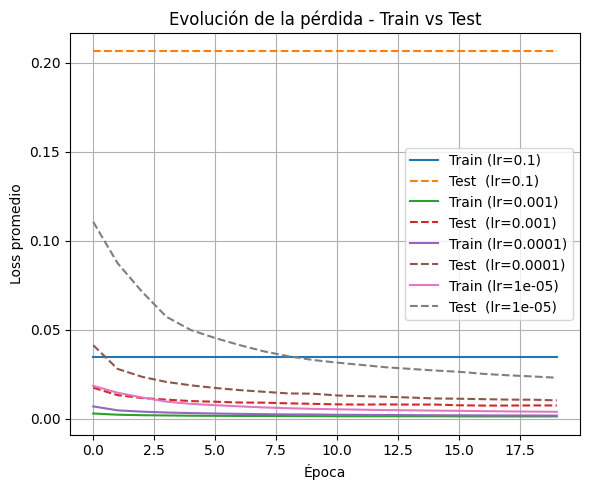

In [96]:
plt.figure(figsize=(6,5))

for lr, data in results.items():
    print(data["train_loss"])
    print(data["test_loss"])
    plt.plot(data["train_loss"], label=f"Train (lr={lr})", linestyle='-')
    plt.plot(data["test_loss"],  label=f"Test  (lr={lr})", linestyle='--')

plt.title("Evolución de la pérdida - Train vs Test")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
data["train_loss"]

In [ ]:
data["test_loss"]

### Veamos la cantidad de epocas:

In [17]:
avg_train_loss = []
avg_test_loss = []

lr = 0.001
epochs = 50
dropout_score = 0.2 
AutoEncoder_model = AutoEncoder(drop_out=dropout_score).to(device)

AE_optimizer = torch.optim.Adam(params=AutoEncoder_model.parameters(), lr=lr)


avg_train_loss, avg_test_loss = train_test(train_loader, test_loader, AutoEncoder_model,
                                                     AE_optimizer, loss_function, epochs)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26


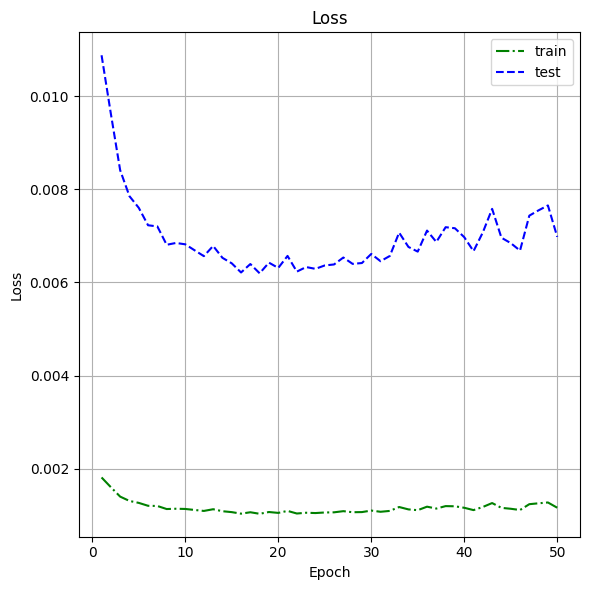

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

ax.plot(range(1, len(avg_train_loss)+1), avg_train_loss,
        label='train', linestyle='-.', c='green')

ax.plot(range(1, len(avg_test_loss)+1), avg_test_loss,
        label='test', linestyle='--', c='blue')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# Entrenemos el autoencoder con los mejores hiperparametros

In [38]:
# Optimizer for our AutoEnconder:
lr_last = 0.001

epochs = 20
loss_function = nn.MSELoss() # Medium Squared Error 

# Create our model:
AutoEncoder_model_last = AutoEncoder(drop_out=0.2).to(device)
AE_optimizer = torch.optim.Adam(params=AutoEncoder_model_last.parameters(), lr=lr_last)
#AutoEncoder_model = AutoEncoder_model.to(device)

avg_train_loss = []
avg_test_loss = []
avg_train_loss, avg_test_loss = train_test(train_loader, test_loader, AutoEncoder_model_last,
                                                     AE_optimizer, loss_function, epochs)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------


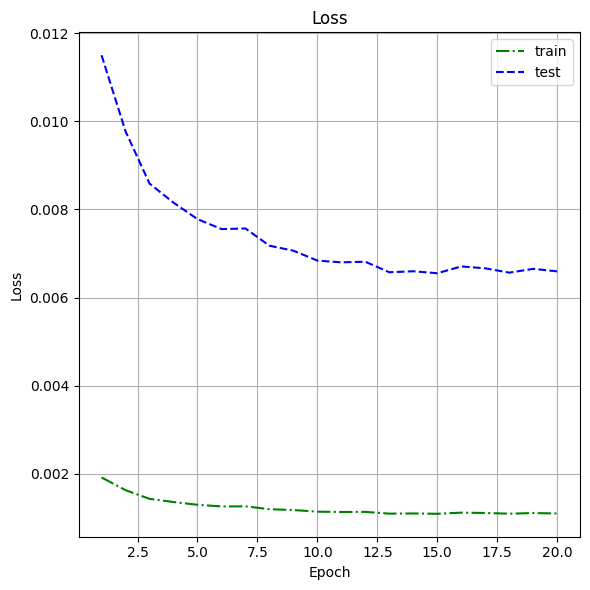

In [39]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

ax.plot(range(1, len(avg_train_loss)+1), avg_train_loss,
        label='train', linestyle='-.', c='green')

ax.plot(range(1, len(avg_test_loss)+1), avg_test_loss,
        label='test', linestyle='--', c='blue')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [40]:
avg_train_loss, avg_test_loss

([0.001916647464968264,
  0.0016288618387964864,
  0.0014312615542051692,
  0.0013590381637526056,
  0.0012967816133362552,
  0.0012590735199240347,
  0.001261364564920465,
  0.0011961136323710283,
  0.0011772407276245454,
  0.001139857643439124,
  0.001133330799639225,
  0.0011354487272910775,
  0.0010958007706018786,
  0.0010994778230475882,
  0.0010920629712442558,
  0.0011177747299273809,
  0.0011107172714546322,
  0.001094280153978616,
  0.0011087103739070396,
  0.0010990727464668454],
 [0.011499884834513068,
  0.00977317100390792,
  0.008587569376453757,
  0.008154228948056699,
  0.007780689673498273,
  0.007554441123269498,
  0.007568187421187759,
  0.00717668183427304,
  0.007063444370403886,
  0.00683914586622268,
  0.006799984822981059,
  0.006812692351639271,
  0.006574804629199207,
  0.006596866969950497,
  0.006552377838641405,
  0.00670664840284735,
  0.0066643036482855675,
  0.0065656808400526645,
  0.0066522622257471084,
  0.006594436482526362])

In [41]:
### Guardemos nuestro autoencoder entrenado:
torch.save(AutoEncoder_model_last, 'autoencoder_trained.pth')

__main__.AutoEncoder

# <center> Creemos nuestro clasificador </center>

In [75]:
class Classifier_conv(nn.Module):
    def __init__(self, autoencoder, encoder_output_dim):
        super().__init__()
    
        # Copy encoder:
        self.encoder = copy.deepcopy(autoencoder.encoder)

        # Create our classifier:
        self.classifier = nn.Sequential(
            nn.Linear(encoder_output_dim, 10)
        )
    def forward(self, x):
        x_hat = self.encoder(x)
        z = self.classifier(x_hat)
        return z                

In [28]:
def train_loop(train_loader, model, loss_fn, optimizer):
    # Set model to be trained
    model.train()
    
    num_samples = len(train_loader.dataset)
    num_batches = len(train_loader)
    sum_batch_avg_loss = 0
    batch_avg_loss = 0
    num_processed_samples = 0
    avg_loss = 0
    sum_correct = 0
    
    for batch, (X,y) in enumerate(train_loader):
        X.to(device)
        y.to(device)
        batch_size = len(X)
        num_processed_samples += batch_size
        
        # Predict our input
        y_train_pred = model(X)    
        
        # Get loss from the prediction
        loss = loss_fn(y_train_pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Get loss per batch
        batch_avg_loss = loss.item() 

        # Get True Positives
        sum_correct += (y_train_pred.argmax(1) == y).type(torch.float).sum().item()        
        # Get total loss value
        sum_batch_avg_loss += batch_avg_loss
            
                       
    avg_loss = sum_batch_avg_loss/num_batches
    accuracy = sum_correct/num_samples
    return avg_loss, accuracy

In [29]:
def test_loop(test_loader, my_model, loss_fn):
    # Set test mode
    my_model.eval()
    sum_correct = 0
    sum_samples = 0
    sum_loss = 0
    num_batches = len(test_loader)
    all_preds = []
    all_labels = []
    # Deactivate gradient calculation:
    with torch.no_grad():
        for X, y in test_loader:
            X.to(device)
            y.to(device)
            sum_samples += len(X)
            # Predicting using our model
            pred_test = my_model(X)
                       
            # Calculating loss:
            loss = loss_fn(pred_test, y)
            sum_loss += loss.item() * len(X)
            # Get True Positives
            sum_correct += (pred_test.argmax(1) == y).type(torch.float).sum().item()
            # Get information to create our confusion matrix
            all_preds.extend(pred_test.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)        
    avrg_loss = sum_loss/sum_samples
    precision = sum_correct/sum_samples
    return avrg_loss, precision, cm

In [58]:
AutoEncoder_pre_trained = torch.load('autoencoder_trained.pth')
#AutoEncoder_pre_trained.eval()


#conv_classifier = Classifier_conv(AutoEncoder_pre_trained, 784)

In [79]:
batch_size = 20
train_loader_classifier = DataLoader(train_set_orig, batch_size=batch_size, shuffle=True)
test_loader_classifier = DataLoader(valid_set_orig, batch_size=batch_size, shuffle=True)

In [80]:
print(f"El dataset de entreamiento tiene: {train_loader_classifier.dataset}")
print(f"El dataset de testeo tiene: {test_loader_classifier.dataset}")

El dataset de entreamiento tiene: Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: MNIST_data/
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )
El dataset de testeo tiene: Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: MNIST_data/
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
           )


Feature batch shape: torch.Size([20, 1, 28, 28])
Labels batch shape: torch.Size([20])


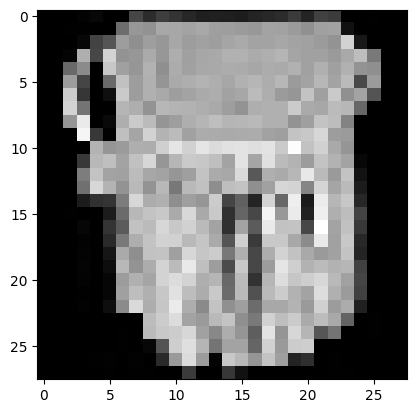

Label: 8


In [81]:
# Display image and label.
train_features, train_labels = next(iter(train_loader_classifier))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [82]:
loss_fn = nn.CrossEntropyLoss()

In [83]:
lr = 0.001
optimizer = torch.optim.Adam(conv_classifier.classifier.parameters(), lr=lr)
conv_classifier.to(device)

Classifier_conv(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=1568, out_features=784, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=10, bias=True)
  )
)

In [84]:
epochs = 20
list_train_avg_loss = []
list_test_avg_loss = []
list_train_accuracy = []
list_test_accuracy = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc, train_acc_inc = train_loop(train_loader_classifier,
                                                 conv_classifier,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss, train_acc, cm = test_loop(train_loader_classifier,
                                        conv_classifier,
                                        loss_fn)

    test_avg_loss, test_acc, cm = test_loop(test_loader_classifier,
                                        conv_classifier,
                                        loss_fn)

    list_train_avg_loss.append(train_avg_loss)
    list_test_avg_loss.append(test_avg_loss)

    list_train_accuracy.append(train_acc)
    list_test_accuracy.append(test_acc)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------


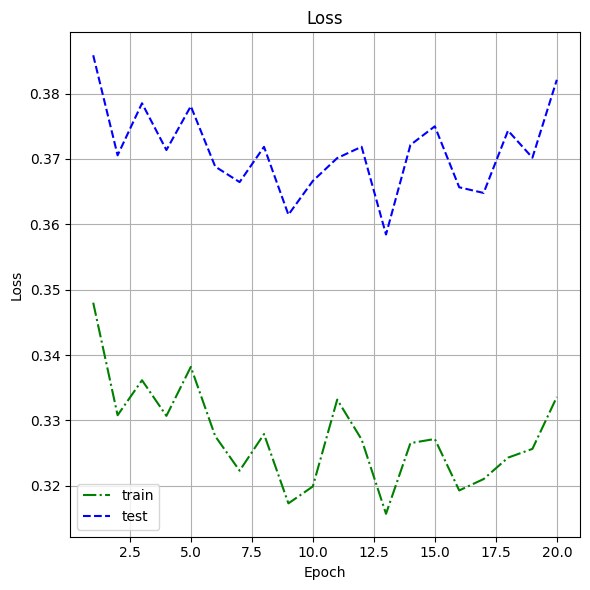

In [85]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

ax.plot(range(1, len(list_train_avg_loss)+1), list_train_avg_loss,
        label='train', linestyle='-.', c='green')

ax.plot(range(1, len(list_test_avg_loss)+1), list_test_avg_loss,
        label='test', linestyle='--', c='blue')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

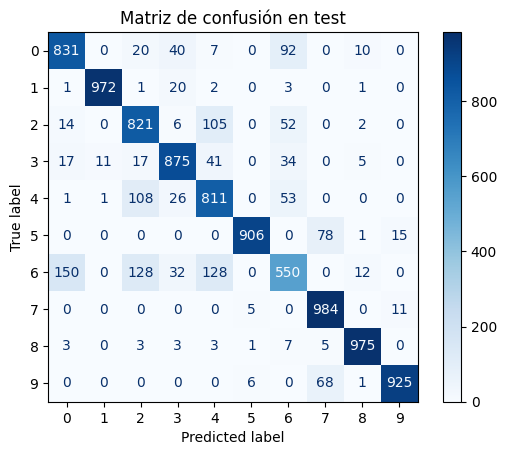

In [86]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format="d")
plt.title("Matriz de confusión en test")
plt.show()

In [90]:
list_train_avg_loss[-1], list_test_avg_loss[-1]

(0.33359305406920614, 0.38210782476514576)

In [89]:
 list_train_accuracy[-1], list_test_accuracy[-1]

(0.8788, 0.865)

### Agreguemos una capa mas con dropout:

In [158]:
class Classifier_conv2(nn.Module):
    def __init__(self, autoencoder, encoder_output_dim, p):
        super().__init__()
    
        # Copy encoder:
        self.encoder = copy.deepcopy(autoencoder.encoder)

        # Create our classifier:
        self.classifier = nn.Sequential(
            nn.Linear(encoder_output_dim, 512),
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 2
            nn.Linear(512, 10), # Capa con 128 entradas y 64 salidas
            )
    def forward(self, x):
        x_hat = self.encoder(x)
        z = self.classifier(x_hat)
        return z   

In [159]:
lr = 0.0001
conv_classifier_2 = Classifier_conv2(AutoEncoder_pre_trained, 784, 0.2)
optimizer = torch.optim.Adam(conv_classifier_2.classifier.parameters(), lr=lr)
conv_classifier_2.to(device)

Classifier_conv2(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=1568, out_features=784, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [166]:
epochs = 40
list_train_avg_loss = []
list_test_avg_loss = []
list_train_accuracy = []
list_test_accuracy = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc, train_acc_inc = train_loop(train_loader_classifier,
                                                 conv_classifier_2,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss, train_acc, cm = test_loop(train_loader_classifier,
                                        conv_classifier_2,
                                        loss_fn)

    test_avg_loss, test_acc, cm = test_loop(test_loader_classifier,
                                        conv_classifier_2,
                                        loss_fn)

    list_train_avg_loss.append(train_avg_loss)
    list_test_avg_loss.append(test_avg_loss)

    list_train_accuracy.append(train_acc)
    list_test_accuracy.append(test_acc)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26


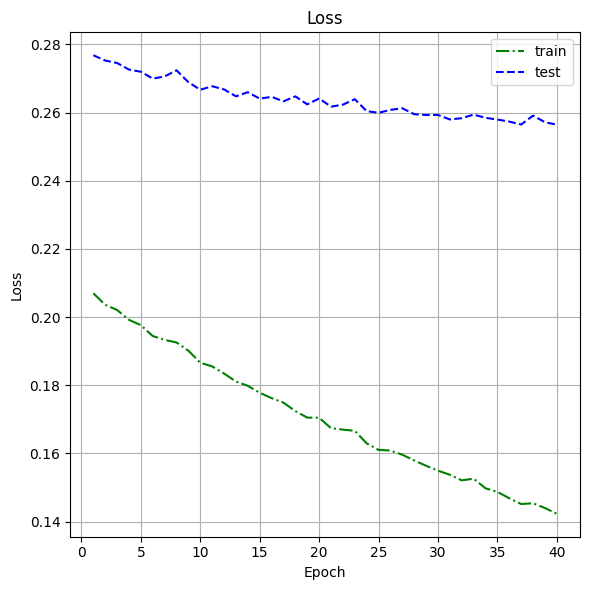

In [167]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

ax.plot(range(1, len(list_train_avg_loss)+1), list_train_avg_loss,
        label='train', linestyle='-.', c='green')

ax.plot(range(1, len(list_test_avg_loss)+1), list_test_avg_loss,
        label='test', linestyle='--', c='blue')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

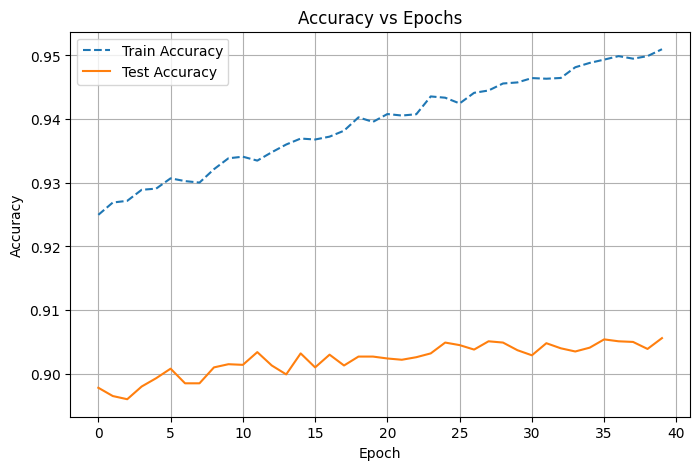

In [168]:
plt.figure(figsize=(8,5))
plt.plot(list_train_accuracy, label="Train Accuracy", linestyle="--")
plt.plot(list_test_accuracy, label="Test Accuracy", linestyle="-")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

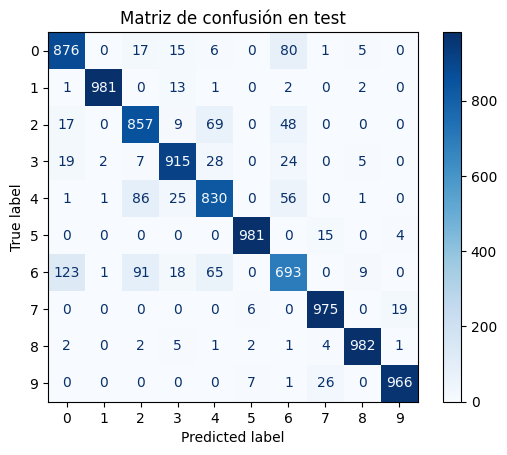

In [169]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format="d")
plt.title("Matriz de confusión en test")
plt.show()

In [170]:
list_train_avg_loss[-1], list_test_avg_loss[-1]

(0.14227242693305014, 0.25645573168992997)

In [171]:
list_train_accuracy[-1], list_test_accuracy[-1]

(0.9509833333333333, 0.9056)

### Una tercera capa:

In [175]:
class Classifier_conv3(nn.Module):
    def __init__(self, autoencoder, encoder_output_dim, p):
        super().__init__()
    
        # Copy encoder:
        self.encoder = copy.deepcopy(autoencoder.encoder)

        # Create our classifier:
        self.classifier = nn.Sequential(
            nn.Linear(encoder_output_dim, 512),
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 2
            nn.Linear(512, 256), # Capa con 128 entradas y 64 salidas
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 3
            nn.Linear(256,10), # Capa final con 10 salidas
            )
    def forward(self, x):
        x_hat = self.encoder(x)
        z = self.classifier(x_hat)
        return z 

In [176]:
lr = 0.0001
conv_classifier_3 = Classifier_conv3(AutoEncoder_pre_trained, 784, 0.2)
optimizer = torch.optim.Adam(conv_classifier_3.classifier.parameters(), lr=lr)
conv_classifier_3.to(device)

Classifier_conv3(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=1568, out_features=784, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [177]:
epochs = 30
list_train_avg_loss = []
list_test_avg_loss = []
list_train_accuracy = []
list_test_accuracy = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc, train_acc_inc = train_loop(train_loader_classifier,
                                                 conv_classifier_3,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss, train_acc, cm = test_loop(train_loader_classifier,
                                        conv_classifier_3,
                                        loss_fn)

    test_avg_loss, test_acc, cm = test_loop(test_loader_classifier,
                                        conv_classifier_3,
                                        loss_fn)

    list_train_avg_loss.append(train_avg_loss)
    list_test_avg_loss.append(test_avg_loss)

    list_train_accuracy.append(train_acc)
    list_test_accuracy.append(test_acc)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26


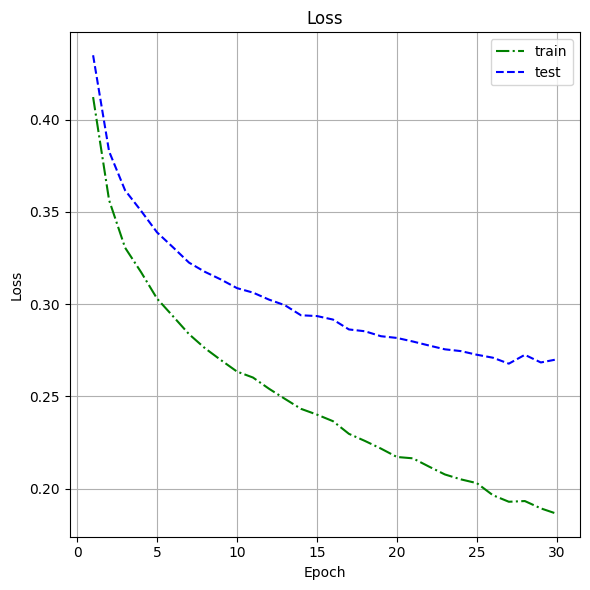

In [178]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

ax.plot(range(1, len(list_train_avg_loss)+1), list_train_avg_loss,
        label='train', linestyle='-.', c='green')

ax.plot(range(1, len(list_test_avg_loss)+1), list_test_avg_loss,
        label='test', linestyle='--', c='blue')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(list_train_accuracy, label="Train Accuracy", linestyle="--")
plt.plot(list_test_accuracy, label="Test Accuracy", linestyle="-")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

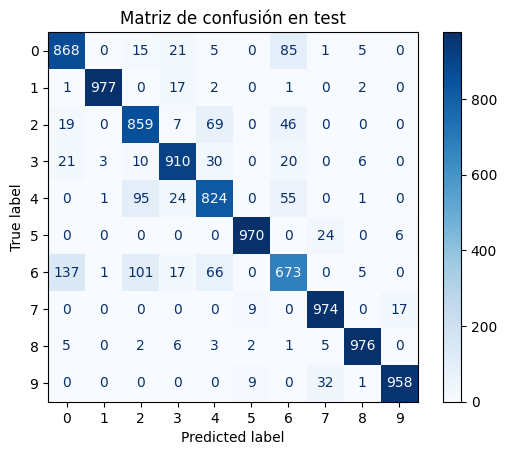

In [179]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format="d")
plt.title("Matriz de confusión en test")
plt.show()

In [180]:
list_train_avg_loss[-1], list_test_avg_loss[-1]

(0.18629253685474395, 0.2699911093711853)

In [181]:
list_train_accuracy[-1], list_test_accuracy[-1]

(0.9315, 0.8989)

### Cuarta capa:

In [25]:
class Classifier_conv6(nn.Module):
    def __init__(self, autoencoder, encoder_output_dim, p):
        super().__init__()
    
        # Copy encoder:
        self.encoder = copy.deepcopy(autoencoder.encoder)

        # Create our classifier:
        self.classifier = nn.Sequential(
            nn.Linear(encoder_output_dim, 512),
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 2
            nn.Linear(512, 256), # Capa con 128 entradas y 64 salidas
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 3
            nn.Linear(256, 128), # Capa con 128 entradas y 64 salidas
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 4
            nn.Linear(128,10), # Capa final con 10 salidas
            )
    def forward(self, x):
        x_hat = self.encoder(x)
        z = self.classifier(x_hat)
        return z 

In [110]:
lr = 0.0001
conv_classifier_6 = Classifier_conv6(AutoEncoder_pre_trained, 784, 0.2)
optimizer = torch.optim.Adam(conv_classifier_6.classifier.parameters(), lr=lr)
conv_classifier_6.to(device)

Classifier_conv6(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=1568, out_features=784, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_featur

In [75]:
epochs = 30
list_train_avg_loss = []
list_test_avg_loss = []
list_train_accuracy = []
list_test_accuracy = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc, train_acc_inc = train_loop(train_loader_classifier,
                                                 conv_classifier_6,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss, train_acc, cm = test_loop(train_loader_classifier,
                                        conv_classifier_6,
                                        loss_fn)

    test_avg_loss, test_acc, cm = test_loop(test_loader_classifier,
                                        conv_classifier_6,
                                        loss_fn)

    list_train_avg_loss.append(train_avg_loss)
    list_test_avg_loss.append(test_avg_loss)

    list_train_accuracy.append(train_acc)
    list_test_accuracy.append(test_acc)

Epoch 1
------------------------------


NameError: name 'conv_classifier_6' is not defined

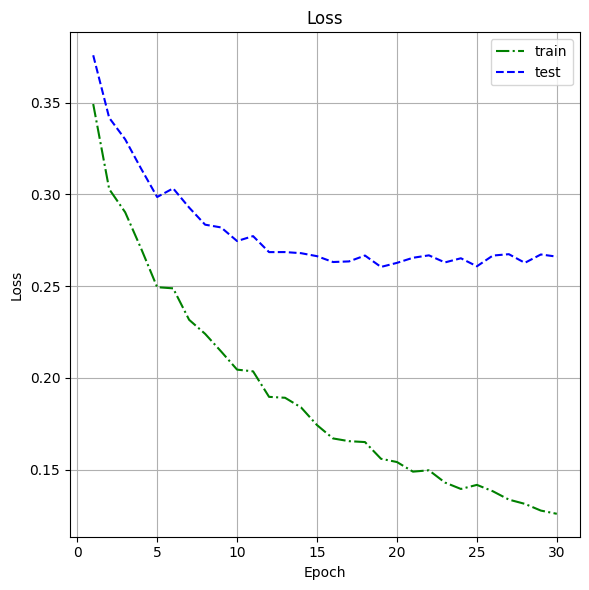

In [112]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

ax.plot(range(1, len(list_train_avg_loss)+1), list_train_avg_loss,
        label='train', linestyle='-.', c='green')

ax.plot(range(1, len(list_test_avg_loss)+1), list_test_avg_loss,
        label='test', linestyle='--', c='blue')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

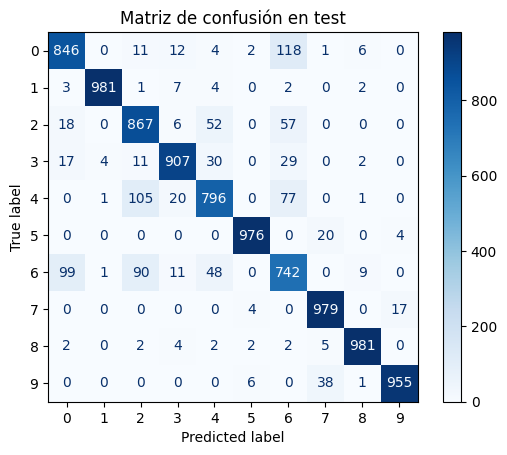

In [113]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format="d")
plt.title("Matriz de confusión en test")
plt.show()

In [114]:
list_train_avg_loss[-1], list_test_avg_loss[-1]

(0.12586761294848597, 0.26605725308135153)

In [115]:
list_train_accuracy[-1], list_test_accuracy[-1]

(0.9556833333333333, 0.903)

### Cambiemos la cantidad de neuronas:

In [196]:
class Classifier_conv4(nn.Module):
    def __init__(self, autoencoder, encoder_output_dim, p):
        super().__init__()
    
        # Copy encoder:
        self.encoder = copy.deepcopy(autoencoder.encoder)

        # Create our classifier:
        self.classifier = nn.Sequential(
            nn.Linear(encoder_output_dim, 128),
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 2
            nn.Linear(128, 64), # Capa con 128 entradas y 64 salidas
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 3
            nn.Linear(64, 32), # Capa con 128 entradas y 64 salidas
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 4
            nn.Linear(32,10), # Capa final con 10 salidas
            )
            
    def forward(self, x):
        x_hat = self.encoder(x)
        z = self.classifier(x_hat)
        return z 

In [197]:
lr = 0.0001
AutoEncoder_not_trained = AutoEncoder(0.2)
conv_classifier_4 = Classifier_conv4(AutoEncoder_pre_trained, 784, 0.2)
optimizer = torch.optim.Adam(conv_classifier_4.classifier.parameters(), lr=lr)
conv_classifier_4.to(device)

Classifier_conv4(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=1568, out_features=784, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=

In [198]:
epochs = 30
list_train_avg_loss = []
list_test_avg_loss = []
list_train_accuracy = []
list_test_accuracy = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc, train_acc_inc = train_loop(train_loader_classifier,
                                                 conv_classifier_4,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss, train_acc, cm = test_loop(train_loader_classifier,
                                        conv_classifier_4,
                                        loss_fn)

    test_avg_loss, test_acc, cm = test_loop(test_loader_classifier,
                                        conv_classifier_4,
                                        loss_fn)

    list_train_avg_loss.append(train_avg_loss)
    list_test_avg_loss.append(test_avg_loss)

    list_train_accuracy.append(train_acc)
    list_test_accuracy.append(test_acc)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26


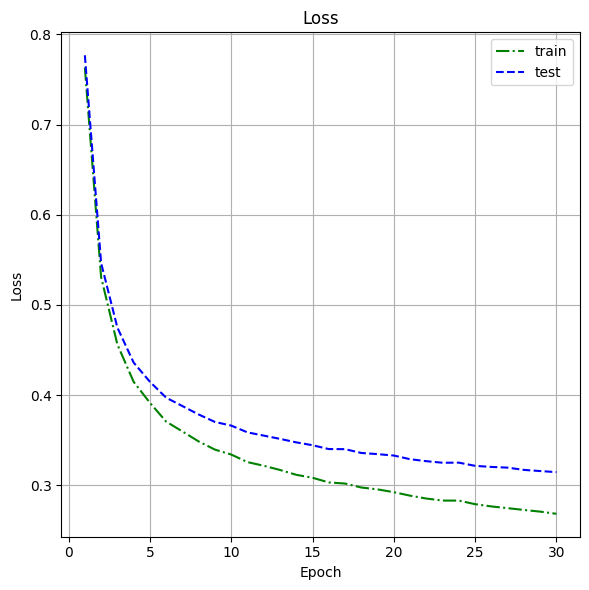

In [199]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

ax.plot(range(1, len(list_train_avg_loss)+1), list_train_avg_loss,
        label='train', linestyle='-.', c='green')

ax.plot(range(1, len(list_test_avg_loss)+1), list_test_avg_loss,
        label='test', linestyle='--', c='blue')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

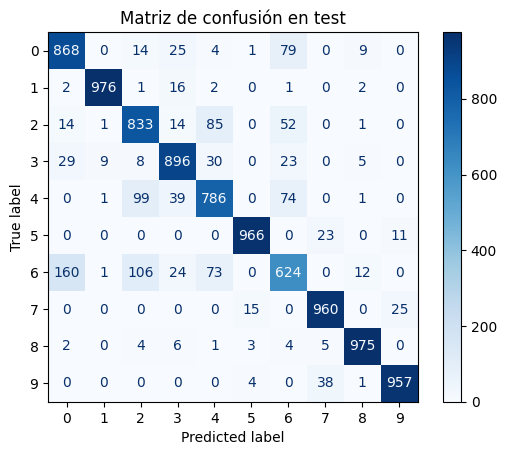

In [200]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format="d")
plt.title("Matriz de confusión en test")
plt.show()

In [201]:
list_train_avg_loss[-1], list_test_avg_loss[-1]

(0.26833885863423346, 0.3145259055495262)

In [202]:
list_train_accuracy[-1], list_test_accuracy[-1]

(0.9012666666666667, 0.8841)

### Bajemos una vez mas las neuronas:

In [115]:
class Classifier_conv5(nn.Module):
    def __init__(self, autoencoder, encoder_output_dim, p):
        super().__init__()
    
        # Copy encoder:
        self.encoder = copy.deepcopy(autoencoder.encoder)

        # Create our classifier:
        self.classifier = nn.Sequential(
            nn.Linear(encoder_output_dim, 64),
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 2
            nn.Linear(64, 32), # Capa con 128 entradas y 64 salidas
            nn.ReLU(), # Funcion de activacion
            nn.Dropout(p),
            # Capa 3
            nn.Linear(32,10), # Capa final con 10 salidas
            )
    def forward(self, x):
        x_hat = self.encoder(x)
        z = self.classifier(x_hat)
        return z 

In [116]:
lr = 0.001
conv_classifier_5 = Classifier_conv(AutoEncoder_pre_trained, 784, 0.2)
optimizer = torch.optim.Adam(conv_classifier_5.classifier.parameters(), lr=lr)
conv_classifier_5.to(device)


epochs = 30
list_train_avg_loss = []
list_test_avg_loss = []
list_train_accuracy = []
list_test_accuracy = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc, train_acc_inc = train_loop(train_loader_classifier,
                                                 conv_classifier_5,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss, train_acc, cm = test_loop(train_loader_classifier,
                                        conv_classifier_5,
                                        loss_fn)

    test_avg_loss, test_acc, cm = test_loop(test_loader_classifier,
                                        conv_classifier_5,
                                        loss_fn)

    list_train_avg_loss.append(train_avg_loss)
    list_test_avg_loss.append(test_avg_loss)

    list_train_accuracy.append(train_acc)
    list_test_accuracy.append(test_acc)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26


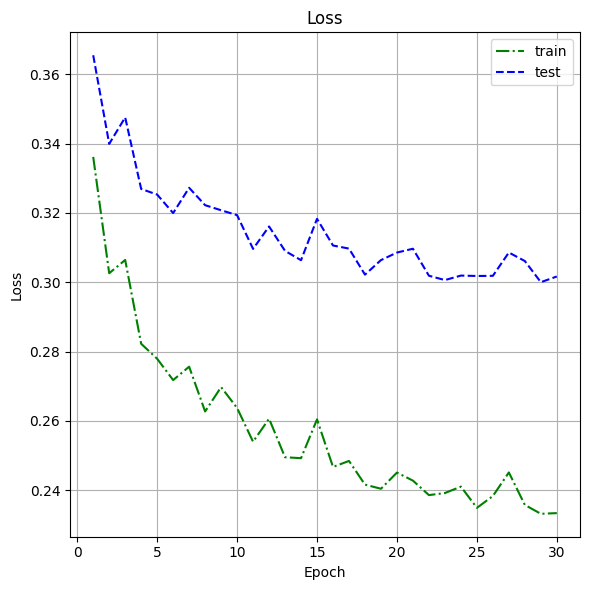

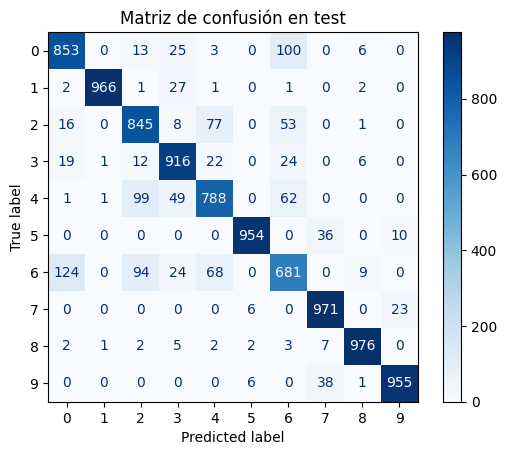

In [117]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

ax.plot(range(1, len(list_train_avg_loss)+1), list_train_avg_loss,
        label='train', linestyle='-.', c='green')

ax.plot(range(1, len(list_test_avg_loss)+1), list_test_avg_loss,
        label='test', linestyle='--', c='blue')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format="d")
plt.title("Matriz de confusión en test")
plt.show()

In [118]:
list_train_avg_loss[-1], list_test_avg_loss[-1]

(0.23334272025463482, 0.3016631113048643)

In [119]:
list_train_accuracy[-1], list_test_accuracy[-1]

(0.9117333333333333, 0.8905)

In [78]:
def train_test(train_loader_classifier, test_loader_classifier, loss_fn, model, optimizer, epochs):
    epochs = epochs
    list_train_avg_loss = []
    list_test_avg_loss = []
    list_train_accuracy = []
    list_test_accuracy = []
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n------------------------------")
        train_avg_loss_inc, train_acc_inc = train_loop(train_loader_classifier,
                                                     model,
                                                     loss_fn,
                                                     optimizer)
        train_avg_loss, train_acc, cm = test_loop(train_loader_classifier,
                                            model,
                                            loss_fn)

        test_avg_loss, test_acc, cm = test_loop(test_loader_classifier,
                                            model,
                                            loss_fn)

        list_train_avg_loss.append(train_avg_loss)
        list_test_avg_loss.append(test_avg_loss)

        list_train_accuracy.append(train_acc)
        list_test_accuracy.append(test_acc)

    return (list_train_avg_loss, list_test_avg_loss, list_train_accuracy, list_test_accuracy, cm)

### Variemos nuestro lr:

In [83]:
learning_rates = [0.0001, 0.1, 0.001]
epochs = 30

# Diccionarios para guardar resultados
results = {}

for lr in learning_rates:
    print(f"\n🔹 Entrenando con learning rate = {lr}")
    # Crear modelo NUEVO para cada experimento
    conv_classifier = Classifier_conv6(AutoEncoder_pre_trained, 784, 0.2)
    optimizer = torch.optim.Adam(conv_classifier.classifier.parameters(), lr=lr)
    conv_classifier.to(device)


    list_train_avg_loss, list_test_avg_loss, list_train_accuracy, list_test_accuracy, cm = train_test(train_loader_classifier,
                                                                                                  test_loader_classifier,
                                                                                                  loss_fn,
                                                                                                  conv_classifier,
                                                                                                  optimizer,
                                                                                                  epochs)
    # Guardar resultados
    results[lr] = {
        "train_loss": list_train_avg_loss,
        "test_loss": list_test_avg_loss,
        "train_acc": list_train_accuracy,
        "test_acc": list_test_accuracy,
        "cm": cm
    }
    print(list_train_accuracy[-1], list_test_accuracy[-1])



🔹 Entrenando con learning rate = 0.0001
Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25

KeyboardInterrupt: 

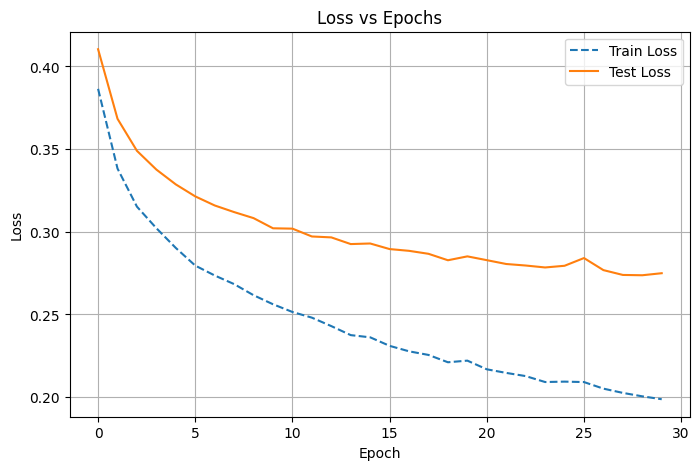

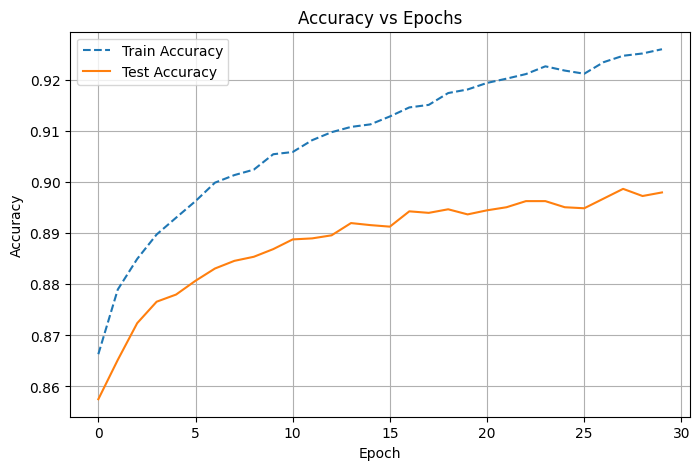

In [122]:
# -----------------------------
# 1. CURVA DE LOSS
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_avg_loss, label="Train Loss", linestyle="--")
plt.plot(list_test_avg_loss, label="Test Loss", linestyle="-")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2. CURVA DE ACCURACY
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_accuracy, label="Train Accuracy", linestyle="--")
plt.plot(list_test_accuracy, label="Test Accuracy", linestyle="-")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

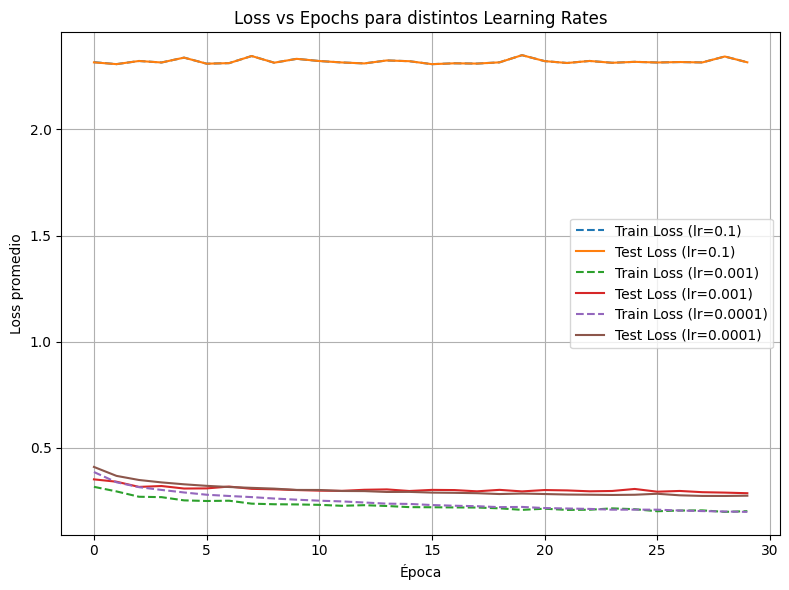

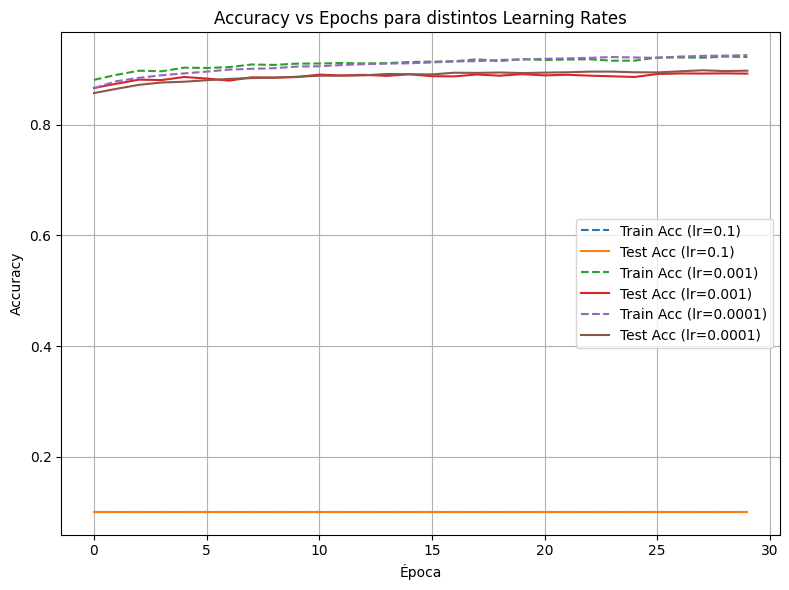

In [123]:
import matplotlib.pyplot as plt

# ======================================================
# 1. GRÁFICO ÚNICO: LOSS (train + test juntos)
# ======================================================
plt.figure(figsize=(8,6))

for lr, data in results.items():
    # Train loss (línea punteada)
    plt.plot(data["train_loss"], linestyle='--', label=f"Train Loss (lr={lr})")
    # Test loss (línea sólida)
    plt.plot(data["test_loss"], linestyle='-',  label=f"Test Loss (lr={lr})")

plt.title("Loss vs Epochs para distintos Learning Rates")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ======================================================
# 2. GRÁFICO ÚNICO: ACCURACY (train + test juntos)
# ======================================================
plt.figure(figsize=(8,6))

for lr, data in results.items():
    # Train accuracy (línea punteada)
    plt.plot(data["train_acc"], linestyle='--', label=f"Train Acc (lr={lr})")
    # Test accuracy (línea sólida)
    plt.plot(data["test_acc"], linestyle='-',  label=f"Test Acc (lr={lr})")

plt.title("Accuracy vs Epochs para distintos Learning Rates")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [127]:
for lr, data in results.items():
    print(data, lr)

{'train_loss': [2.3168424417177835, 2.30751762620608, 2.3223376820087434, 2.3152670344511668, 2.3381434885660806, 2.309676916599274, 2.3122553475697836, 2.3457398070494335, 2.3142483162879945, 2.332432930469513, 2.322134660959244, 2.315444004138311, 2.310890019416809, 2.3248924673398337, 2.321315103371938, 2.307377803961436, 2.311447768449783, 2.3101163139343264, 2.315929906288783, 2.349731592655182, 2.321801675717036, 2.3128792603015897, 2.3224829471906028, 2.3138831560611726, 2.3183279890219373, 2.315220171054204, 2.3173938809235892, 2.315502897262573, 2.34344834001859, 2.3161062197685243], 'test_loss': [2.315890914440155, 2.307517617702484, 2.322337673664093, 2.3152670202255248, 2.3381434988975527, 2.3096769280433653, 2.312255341053009, 2.3457398056983947, 2.3142483196258543, 2.332432942390442, 2.322134660243988, 2.3154440093040467, 2.3108900179862975, 2.3248924775123596, 2.32131511592865, 2.3073777842521666, 2.311447759628296, 2.310116312980652, 2.3159298977851868, 2.34973159122467

## Batches

In [79]:
epochs = 20
batches = [20, 64, 100, 200]
lr = 0.0001
results = {}

# ------------------------------------------------------
# BUCLE PRINCIPAL: probar varios Epochs
# ------------------------------------------------------
for batch in batches:
    print(f"\n🔹 Entrenando con batch = {batch}")
# Crear modelo NUEVO para cada experimento
    train_loader_classifier = DataLoader(train_set_orig, batch_size=batch, shuffle=True)
    test_loader_classifier = DataLoader(valid_set_orig, batch_size=batch, shuffle=True)
    conv_classifier = Classifier_conv6(AutoEncoder_pre_trained, 784, 0.2)
    optimizer = torch.optim.Adam(conv_classifier.classifier.parameters(), lr=lr)
    conv_classifier.to(device)


    list_train_avg_loss, list_test_avg_loss, list_train_accuracy, list_test_accuracy, cm = train_test(train_loader_classifier,
                                                                                                  test_loader_classifier,
                                                                                                  loss_fn,
                                                                                                  conv_classifier,
                                                                                                  optimizer,
                                                                                                  epochs)
    # Guardar resultados
    results[batch] = {
        "train_loss": list_train_avg_loss,
        "test_loss": list_test_avg_loss,
        "train_acc": list_train_accuracy,
        "test_acc": list_test_accuracy,
        "cm": cm
    }



🔹 Entrenando con batch = 20
Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------

🔹 Entrenando con batch = 64
Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
--------------------------

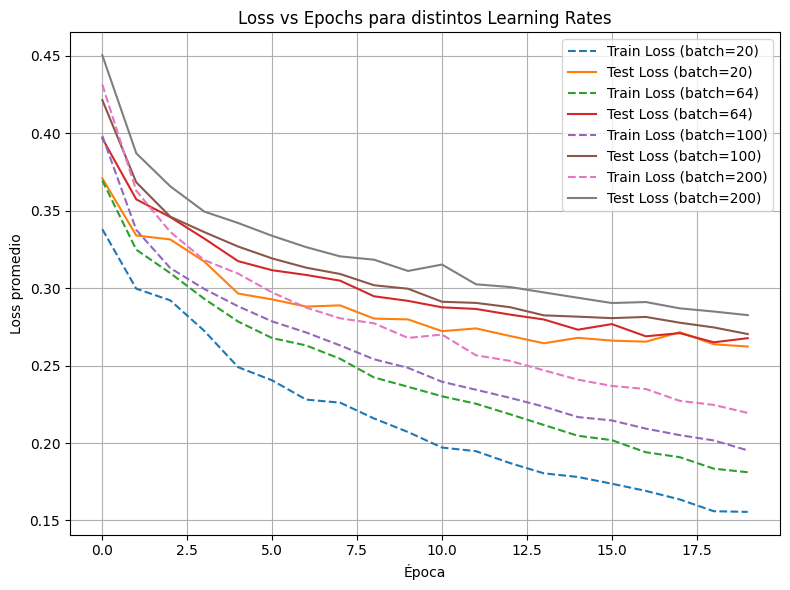

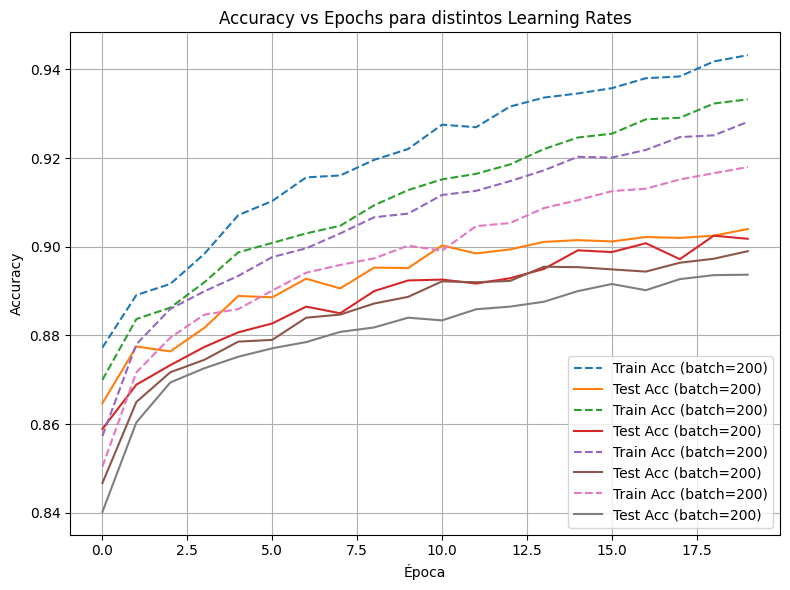

In [80]:
import matplotlib.pyplot as plt

# ======================================================
# 1. GRÁFICO ÚNICO: LOSS (train + test juntos)
# ======================================================
plt.figure(figsize=(8,6))

for batch, data in results.items():
    # Train loss (línea punteada)
    plt.plot(data["train_loss"], linestyle='--', label=f"Train Loss (batch={batch})")
    # Test loss (línea sólida)
    plt.plot(data["test_loss"], linestyle='-',  label=f"Test Loss (batch={batch})")

plt.title("Loss vs Epochs para distintos Learning Rates")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ======================================================
# 2. GRÁFICO ÚNICO: ACCURACY (train + test juntos)
# ======================================================
plt.figure(figsize=(8,6))

for lr, data in results.items():
    # Train accuracy (línea punteada)
    plt.plot(data["train_acc"], linestyle='--', label=f"Train Acc (batch={batch})")
    # Test accuracy (línea sólida)
    plt.plot(data["test_acc"], linestyle='-',  label=f"Test Acc (batch={batch})")

plt.title("Accuracy vs Epochs para distintos Learning Rates")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [81]:
for batch, data in results.items():
    print(data, batch)

{'train_loss': [0.3380508012579133, 0.29962769156880675, 0.2921136142270019, 0.27245794765123477, 0.24894611752436807, 0.24047009292927882, 0.228025806710124, 0.22606541710812597, 0.2158368724503865, 0.20709555483345563, 0.1970677567406868, 0.1947417227208304, 0.18706360404302055, 0.18042816351369645, 0.1780847079216813, 0.17371899252105505, 0.16908867826747398, 0.16356871668458917, 0.15597557053280373, 0.15554165826551616], 'test_loss': [0.37090783020853996, 0.33398784113675356, 0.3314365763142705, 0.31719795436784626, 0.29649134531617166, 0.2927041350342333, 0.28809055802971123, 0.28886420676112173, 0.28034035536646845, 0.27981161188334225, 0.27221477709710595, 0.2739813864380121, 0.26910986966639755, 0.26440468229353425, 0.26790779159218076, 0.2661261644307524, 0.2654186265692115, 0.2715440538339317, 0.26373928448557854, 0.262306115783751], 'train_acc': [0.8772666666666666, 0.8891166666666667, 0.8916166666666666, 0.8983833333333333, 0.9071333333333333, 0.9103166666666667, 0.91565, 0

### Epocas

In [77]:
lr = 0.0001
conv_classifier_6 = Classifier_conv6(AutoEncoder_pre_trained, 784, 0.2)
optimizer = torch.optim.Adam(conv_classifier_6.classifier.parameters(), lr=lr)
conv_classifier_6.to(device)


epochs = 70
list_train_avg_loss = []
list_test_avg_loss = []
list_train_accuracy = []
list_test_accuracy = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc, train_acc_inc = train_loop(train_loader_classifier,
                                                 conv_classifier_6,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss, train_acc, cm = test_loop(train_loader_classifier,
                                        conv_classifier_6,
                                        loss_fn)

    test_avg_loss, test_acc, cm = test_loop(test_loader_classifier,
                                        conv_classifier_6,
                                        loss_fn)

    list_train_avg_loss.append(train_avg_loss)
    list_test_avg_loss.append(test_avg_loss)

    list_train_accuracy.append(train_acc)
    list_test_accuracy.append(test_acc)

Epoch 1
------------------------------


KeyboardInterrupt: 

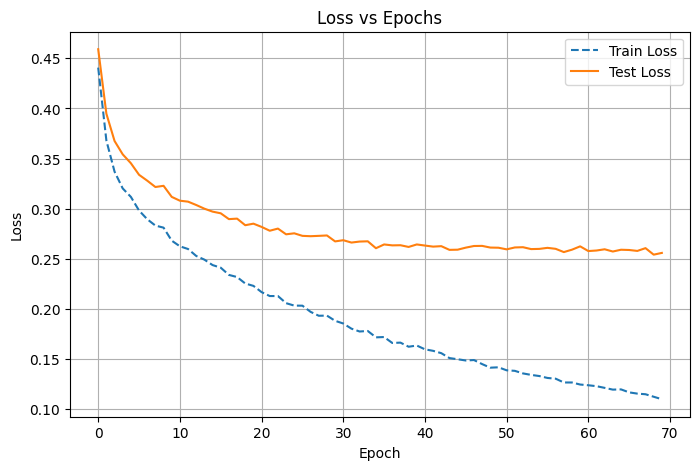

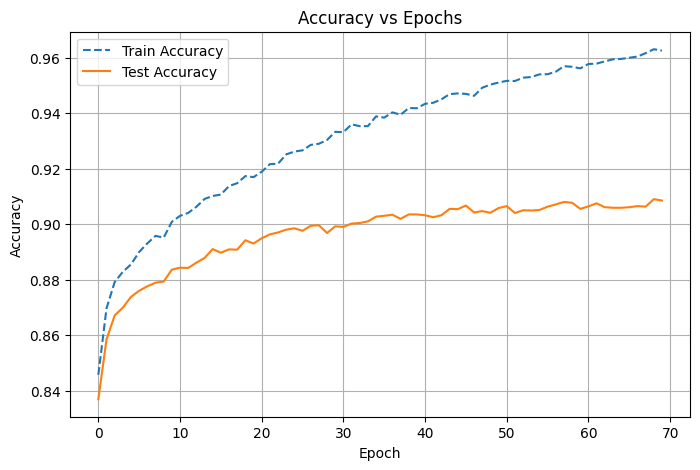

In [204]:
# -----------------------------
# 1. CURVA DE LOSS
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_avg_loss, label="Train Loss", linestyle="--")
plt.plot(list_test_avg_loss, label="Test Loss", linestyle="-")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2. CURVA DE ACCURACY
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_accuracy, label="Train Accuracy", linestyle="--")
plt.plot(list_test_accuracy, label="Test Accuracy", linestyle="-")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Mejor clasificador: 

# <center>Experimentos finales:</center>

In [26]:
loss_fn = nn.CrossEntropyLoss()

### Entrenamiento de Autoencoder y Clasificador DESDE CERO TODO:

In [137]:
lr = 0.0001

train_set = CustomDataset(train_set_orig)
test_set = CustomDataset(valid_set_orig)
batch_size = 20
train_loader_classifier = DataLoader(train_set_orig, batch_size=batch_size, shuffle=True)
test_loader_classifier = DataLoader(valid_set_orig, batch_size=batch_size, shuffle=True)


AutoEncoder_not_trained = AutoEncoder(0.2)
conv_classifier_BA = Classifier_conv6(AutoEncoder_not_trained, 784, 0.2)
optimizer = torch.optim.Adam(conv_classifier_BA.parameters(), lr=lr)
conv_classifier_BA.to(device)


epochs = 40
list_train_avg_loss_exp1 = []
list_test_avg_loss_exp1 = []
list_train_accuracy_exp1 = []
list_test_accuracy_exp1 = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc_exp1, train_acc_inc_exp1 = train_loop(train_loader_classifier,
                                                 conv_classifier_BA,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss_exp1, train_acc_exp1, cm_exp1 = test_loop(train_loader_classifier,
                                        conv_classifier_BA,
                                        loss_fn)

    test_avg_loss_exp1, test_acc_exp1, cm_exp1 = test_loop(test_loader_classifier,
                                        conv_classifier_BA,
                                        loss_fn)

    list_train_avg_loss_exp1.append(train_avg_loss_exp1)
    list_test_avg_loss_exp1.append(test_avg_loss_exp1)

    list_train_accuracy_exp1.append(train_acc_exp1)
    list_test_accuracy_exp1.append(test_acc_exp1)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26


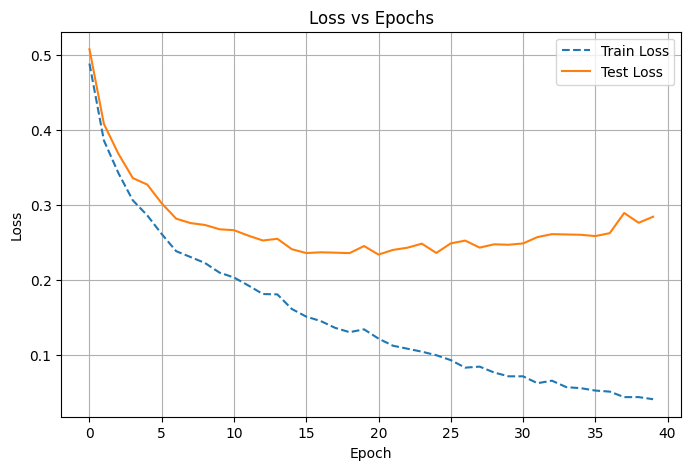

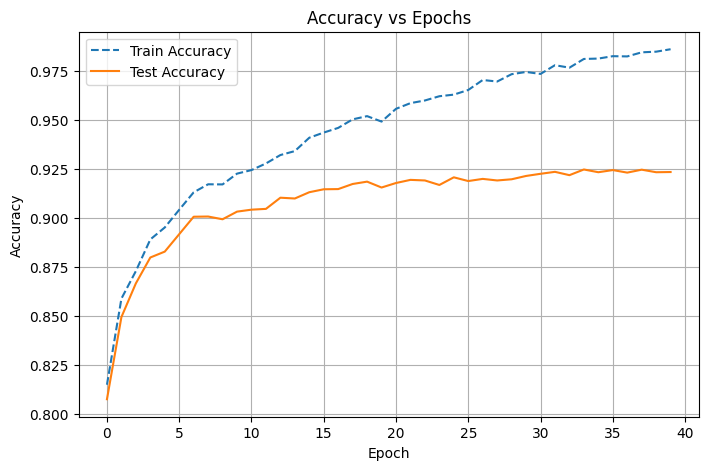

In [138]:
# -----------------------------
# 1. CURVA DE LOSS
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_avg_loss_exp1, label="Train Loss", linestyle="--")
plt.plot(list_test_avg_loss_exp1, label="Test Loss", linestyle="-")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2. CURVA DE ACCURACY
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_accuracy_exp1, label="Train Accuracy", linestyle="--")
plt.plot(list_test_accuracy_exp1, label="Test Accuracy", linestyle="-")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [139]:
list_train_avg_loss_exp1[-1], list_test_avg_loss_exp1[-1]

(0.040629168509488715, 0.28433905340092314)

In [140]:
list_train_accuracy_exp1[-1], list_test_accuracy_exp1[-1]

(0.98605, 0.9234)

In [36]:
list_train_avg_loss

[0.534152470678091,
 0.43390865582351884,
 0.39222294826060533,
 0.350559862618645,
 0.3186264700544998,
 0.2925786113369589,
 0.2711192171163857,
 0.25761927975403764,
 0.23956307318185766,
 0.2426740961248676,
 0.22897509462044885,
 0.2081197724988063,
 0.19622476066136732,
 0.1847616983615638,
 0.17287192535089949,
 0.16779850283171982,
 0.17238904160237872,
 0.164189115509158,
 0.138052436796017,
 0.1375357561778898,
 0.13350404322248263,
 0.12374716786341741,
 0.11330367836980926,
 0.10831700344915346,
 0.10245100118135451,
 0.10015890670478499,
 0.09563979742202597,
 0.09080339022698657,
 0.08000499965479442,
 0.08374412591598956,
 0.07297320790919669,
 0.07321668529746239,
 0.0685791218582405,
 0.06408846220937751,
 0.057054505046107803,
 0.056965954448147386,
 0.058968815070438725,
 0.04896238157436407,
 0.04968119062884944,
 0.04862150224406651]

In [37]:
list_test_avg_loss

[0.551079124212265,
 0.4556347224414349,
 0.4189059565961361,
 0.38020726083964107,
 0.3543165901452303,
 0.33161250987648966,
 0.3121042198687792,
 0.30306557758152486,
 0.2897118812464178,
 0.29591430992633105,
 0.28361653301492334,
 0.2688145931921899,
 0.25937723359651865,
 0.24777800335362554,
 0.24724018352339044,
 0.24000502152275294,
 0.2462353574661538,
 0.2553213462764397,
 0.23325259478669613,
 0.24003312495723367,
 0.23485693494975568,
 0.237518888622988,
 0.23351101883407682,
 0.24094550826400518,
 0.23526782939489932,
 0.24090318906866015,
 0.23839674493018537,
 0.24370431344024837,
 0.24204057182744146,
 0.2442355991275981,
 0.23980667979014106,
 0.2461840022946708,
 0.2580104126421502,
 0.25816965041853834,
 0.2735524652302265,
 0.2601435768837109,
 0.2713945705302758,
 0.27592310730658937,
 0.26611205473693555,
 0.26955804793850985]

In [38]:
list_train_accuracy

[0.79035,
 0.8402166666666666,
 0.8516333333333334,
 0.8712166666666666,
 0.8822833333333333,
 0.8923166666666666,
 0.9015,
 0.9048333333333334,
 0.9103833333333333,
 0.9085833333333333,
 0.9150833333333334,
 0.9210666666666667,
 0.9279666666666667,
 0.9318833333333333,
 0.9369,
 0.9387333333333333,
 0.9374166666666667,
 0.9386,
 0.9482333333333334,
 0.9499666666666666,
 0.9503833333333334,
 0.95485,
 0.9592666666666667,
 0.9607333333333333,
 0.9625333333333334,
 0.9634,
 0.9649,
 0.9664833333333334,
 0.97105,
 0.9700166666666666,
 0.9749,
 0.97315,
 0.9750333333333333,
 0.9761166666666666,
 0.9795,
 0.9798166666666667,
 0.9788,
 0.9821833333333333,
 0.9827333333333333,
 0.98195]

In [39]:
list_test_accuracy

[0.7855,
 0.8339,
 0.8461,
 0.8621,
 0.8712,
 0.8814,
 0.888,
 0.8906,
 0.8949,
 0.8918,
 0.899,
 0.9025,
 0.9082,
 0.9106,
 0.9138,
 0.9135,
 0.911,
 0.9105,
 0.9173,
 0.9167,
 0.9168,
 0.9194,
 0.9209,
 0.9185,
 0.9241,
 0.9198,
 0.9207,
 0.9245,
 0.9218,
 0.9227,
 0.9237,
 0.9237,
 0.9232,
 0.9252,
 0.9219,
 0.9252,
 0.9202,
 0.9224,
 0.9248,
 0.926]

### Entrenamiento DE LA RED ENTERA, PERO CON UN CODIFICADOR PRE ENTRENADO:

In [115]:
lr = 0.0001

train_set = CustomDataset(train_set_orig)
test_set = CustomDataset(valid_set_orig)
batch_size = 20
train_loader_classifier = DataLoader(train_set_orig, batch_size=batch_size, shuffle=True)
test_loader_classifier = DataLoader(valid_set_orig, batch_size=batch_size, shuffle=True)


AutoEncoder_pre_trained = torch.load('autoencoder_trained.pth')
conv_classifier_TAE = Classifier_conv6(AutoEncoder_pre_trained, 784, 0.2)
optimizer = torch.optim.Adam(conv_classifier_TAE.parameters(), lr=lr)
conv_classifier_TAE.to(device)


epochs = 40
list_train_avg_loss_exp2 = []
list_test_avg_loss_exp2 = []
list_train_accuracy_exp2 = []
list_test_accuracy_exp2 = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc_exp2, train_acc_inc_exp2 = train_loop(train_loader_classifier,
                                                 conv_classifier_TAE,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss_exp2, train_acc_exp2, cm_exp2 = test_loop(train_loader_classifier,
                                        conv_classifier_TAE,
                                        loss_fn)

    test_avg_loss_exp2, test_acc_exp2, cm_exp2 = test_loop(test_loader_classifier,
                                        conv_classifier_TAE,
                                        loss_fn)

    list_train_avg_loss_exp2.append(train_avg_loss_exp2)
    list_test_avg_loss_exp2.append(test_avg_loss_exp2)

    list_train_accuracy_exp2.append(train_acc_exp2)
    list_test_accuracy_exp2.append(test_acc_exp2)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26


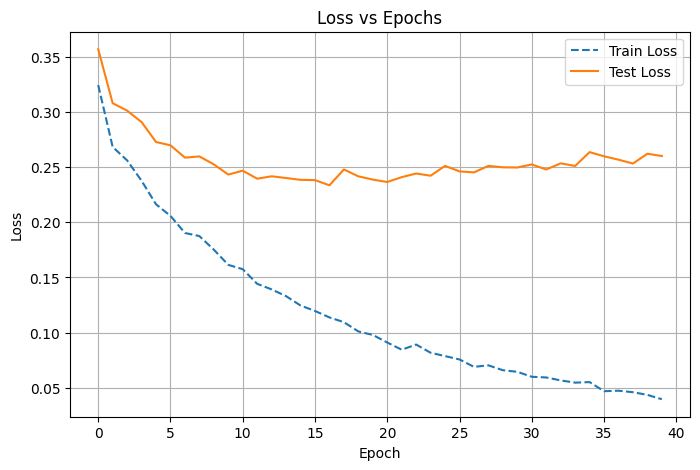

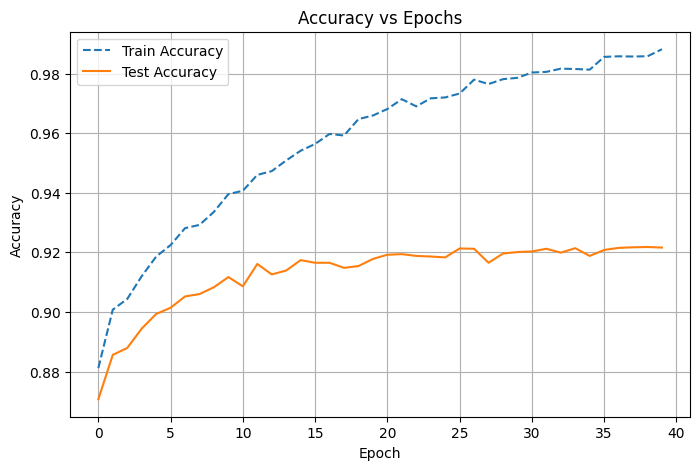

In [116]:
# -----------------------------
# 1. CURVA DE LOSS
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_avg_loss_exp2, label="Train Loss", linestyle="--")
plt.plot(list_test_avg_loss_exp2, label="Test Loss", linestyle="-")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2. CURVA DE ACCURACY
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_accuracy_exp2, label="Train Accuracy", linestyle="--")
plt.plot(list_test_accuracy_exp2, label="Test Accuracy", linestyle="-")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

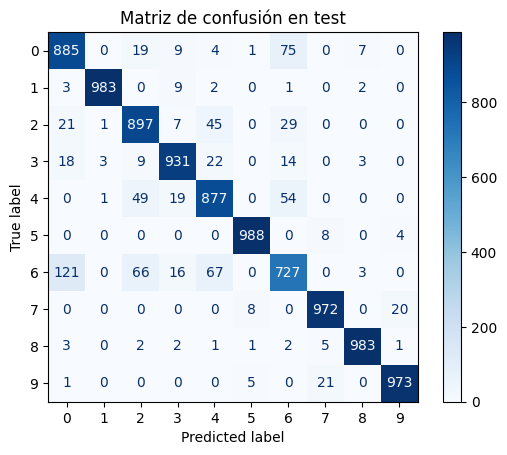

In [117]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_exp2)
disp.plot(cmap='Blues', values_format="d")
plt.title("Matriz de confusión en test")
plt.show()

In [119]:
list_train_avg_loss_exp2[-1], list_test_avg_loss_exp2[-1]

(0.03946701397905114, 0.26017647379210396)

In [120]:
list_train_avg_loss_exp2

[0.3245723794835309,
 0.2684409451658527,
 0.25622024658850084,
 0.23771392887271942,
 0.21639188587339594,
 0.2058308883419571,
 0.19033189834157627,
 0.18752427775599062,
 0.17519440386258064,
 0.16140149832470344,
 0.15748249605313563,
 0.14420101556259518,
 0.13912387898525533,
 0.13299664130108432,
 0.1245052220794217,
 0.11956644286611118,
 0.11370586303225719,
 0.10940067359737198,
 0.1009757134320292,
 0.09781853720582634,
 0.09095038990239845,
 0.08438262809851828,
 0.08907909611034362,
 0.08164781618944834,
 0.07860649069437446,
 0.07556030081179536,
 0.06882880810233473,
 0.07021876367998386,
 0.06578555387056743,
 0.0643427890450063,
 0.05983744268312633,
 0.05921020955552134,
 0.05653660635242704,
 0.05451155200630698,
 0.05500730469062061,
 0.04675913745389941,
 0.047190074260894714,
 0.04582477936613335,
 0.04340214473475983,
 0.03946701397905114]

In [121]:
list_test_avg_loss_exp2

[0.3571048058792949,
 0.30812580465897915,
 0.3013737694658339,
 0.2910033254548907,
 0.2728981580063701,
 0.2699003403726965,
 0.2587420754469931,
 0.25980033695232124,
 0.2526008155234158,
 0.24335421746596694,
 0.2468688959442079,
 0.23960178351961076,
 0.2417814253102988,
 0.24022079806774854,
 0.23855779687687756,
 0.23830761823058128,
 0.23360242997296154,
 0.24800380715355277,
 0.24174956334754824,
 0.23879186121001839,
 0.23659295555669815,
 0.24100620647519827,
 0.24429181652748957,
 0.24230300235957838,
 0.2512297982154414,
 0.24623803263762967,
 0.24533483352744953,
 0.25123431787267325,
 0.24994167967815883,
 0.24977725224546157,
 0.25255677246337294,
 0.2479277724660933,
 0.25355196347786113,
 0.25117053018859586,
 0.26371746787580197,
 0.2599363305899315,
 0.2568536095037125,
 0.2533569341567345,
 0.26226342847186607,
 0.26017647379210396]

In [122]:
list_train_accuracy_exp2[-1], list_test_accuracy_exp2[-1]

(0.9881833333333333, 0.9216)

In [123]:
list_train_accuracy_exp2[-1], list_test_accuracy_exp2[-1]

(0.9881833333333333, 0.9216)

In [124]:
list_train_accuracy_exp2

[0.8811666666666667,
 0.9007666666666667,
 0.90435,
 0.9119833333333334,
 0.9185666666666666,
 0.92245,
 0.9281166666666667,
 0.9292166666666667,
 0.9336,
 0.93955,
 0.9406833333333333,
 0.946,
 0.9472666666666667,
 0.95085,
 0.9541166666666666,
 0.9563833333333334,
 0.95975,
 0.9592166666666667,
 0.9647333333333333,
 0.9659333333333333,
 0.9681166666666666,
 0.9714166666666667,
 0.969,
 0.9717,
 0.972,
 0.9733166666666667,
 0.9779666666666667,
 0.9764833333333334,
 0.9781333333333333,
 0.9785833333333334,
 0.9803666666666667,
 0.9805833333333334,
 0.98165,
 0.98155,
 0.9813166666666666,
 0.9856166666666667,
 0.9858,
 0.9857333333333334,
 0.9858166666666667,
 0.9881833333333333]

In [125]:
list_test_accuracy_exp2

[0.8707,
 0.8856,
 0.8879,
 0.8944,
 0.8993,
 0.9014,
 0.9052,
 0.906,
 0.9083,
 0.9117,
 0.9086,
 0.9161,
 0.9126,
 0.9139,
 0.9174,
 0.9165,
 0.9165,
 0.9148,
 0.9154,
 0.9178,
 0.9192,
 0.9194,
 0.9188,
 0.9186,
 0.9183,
 0.9213,
 0.9212,
 0.9165,
 0.9196,
 0.9201,
 0.9203,
 0.9212,
 0.9199,
 0.9214,
 0.9188,
 0.9208,
 0.9215,
 0.9217,
 0.9218,
 0.9216]

### Entrenamiento DEL CLASIFICADOR, PERO CON UN CODIFICADOR NO ENTRENADO:

In [85]:
def train_loop1(train_loader, model, loss_fn, optimizer):
    # Congelar comportamiento estocástico del encoder (dropout)
    model.encoder.eval()
    # Entrenar solo el clasificador
    model.classifier.train()

    num_samples = len(train_loader.dataset)
    num_batches = len(train_loader)
    total_loss = 0
    total_correct = 0

    for X, y in train_loader:
        
        X = X.to(device)
        y = y.to(device)
        
        # Extraer features sin gradientes
        with torch.no_grad():
            features = model.encoder(X)
        
        # Clasificador sí genera gradientes
        y_pred = model.classifier(features)

        # Calcular loss
        loss = loss_fn(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Acumular métricas
        total_loss += loss.item()
        total_correct += (y_pred.argmax(1) == y).sum().item()

    avg_loss = total_loss / num_batches
    accuracy = total_correct / num_samples
    return avg_loss, accuracy

In [86]:
def test_loop1(test_loader, my_model, loss_fn):
    # Set test mode
    my_model.eval()
    sum_correct = 0
    sum_samples = 0
    sum_loss = 0
    num_batches = len(test_loader)
    all_preds = []
    all_labels = []
    # Deactivate gradient calculation:
    with torch.no_grad():
        for X, y in test_loader:
            X.to(device)
            y.to(device)
            sum_samples += len(X)
            # Predicting using our model
            pred_test = my_model(X)
                       
            # Calculating loss:
            loss = loss_fn(pred_test, y)
            sum_loss += loss.item() * len(X)
            # Get True Positives
            sum_correct += (pred_test.argmax(1) == y).type(torch.float).sum().item()
            # Get information to create our confusion matrix
            all_preds.extend(pred_test.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds,normalize='true')        
    avrg_loss = sum_loss/sum_samples
    precision = sum_correct/sum_samples
    return avrg_loss, precision, cm

In [87]:
lr = 0.0001

train_set = CustomDataset(train_set_orig)
test_set = CustomDataset(valid_set_orig)
batch_size = 20
train_loader_classifier = DataLoader(train_set_orig, batch_size=batch_size, shuffle=True)
test_loader_classifier = DataLoader(valid_set_orig, batch_size=batch_size, shuffle=True)


AutoEncoder_not_trained = AutoEncoder(0.2)
conv_classifier_ENT = Classifier_conv6(AutoEncoder_not_trained, 784, 0.2)
optimizer = torch.optim.Adam(conv_classifier_ENT.classifier.parameters(), lr=lr)
conv_classifier_ENT.to(device)

for p in conv_classifier_ENT.encoder.parameters():
    p.requires_grad = False

import copy

before = copy.deepcopy(conv_classifier_ENT.encoder.state_dict())

epochs = 40
list_train_avg_loss_exp3 = []
list_test_avg_loss_exp3 = []
list_train_accuracy_exp3 = []
list_test_accuracy_exp3 = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc_exp3, train_acc_inc_exp3 = train_loop1(train_loader_classifier,
                                                 conv_classifier_ENT,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss_exp3, train_acc_exp3, cm_exp3 = test_loop1(train_loader_classifier,
                                        conv_classifier_ENT,
                                        loss_fn)

    test_avg_loss_exp3, test_acc_exp3, cm_exp3 = test_loop1(test_loader_classifier,
                                        conv_classifier_ENT,
                                        loss_fn)

    list_train_avg_loss_exp3.append(train_avg_loss_exp3)
    list_test_avg_loss_exp3.append(test_avg_loss_exp3)

    list_train_accuracy_exp3.append(train_acc_exp3)
    list_test_accuracy_exp3.append(test_acc_exp3)

    
after = conv_classifier_ENT.encoder.state_dict()

for k in before:
    if not torch.equal(before[k], after[k]):
        print("⚠ Encoder cambió:", k)
        break
else:
    print("✔ Encoder no cambió: está congelado")    

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26


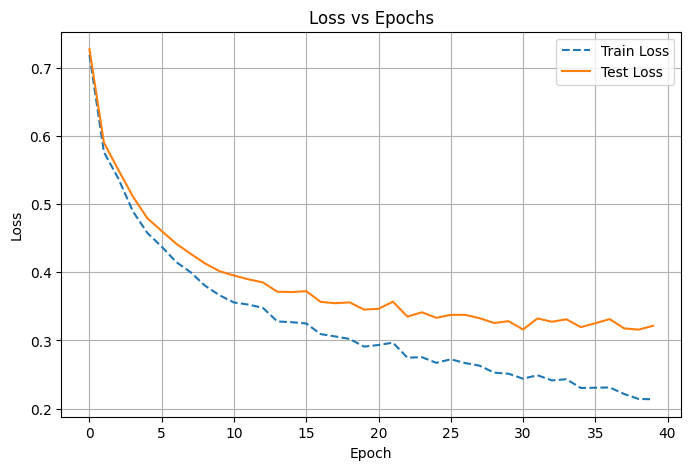

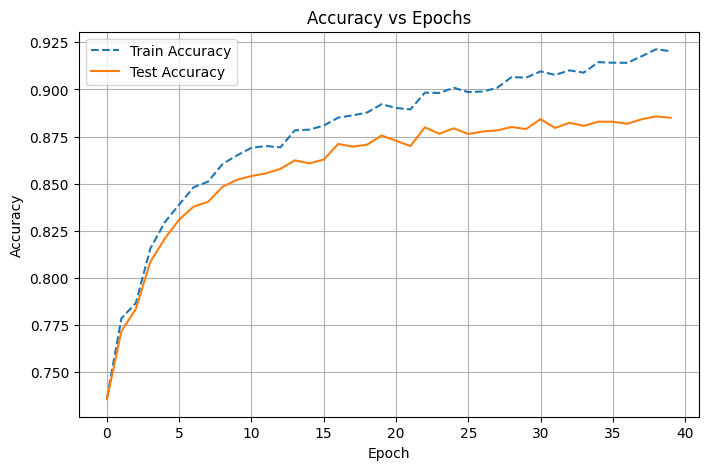

In [88]:
# -----------------------------
# 1. CURVA DE LOSS
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_avg_loss_exp3, label="Train Loss", linestyle="--")
plt.plot(list_test_avg_loss_exp3, label="Test Loss", linestyle="-")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2. CURVA DE ACCURACY
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_accuracy_exp3, label="Train Accuracy", linestyle="--")
plt.plot(list_test_accuracy_exp3, label="Test Accuracy", linestyle="-")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

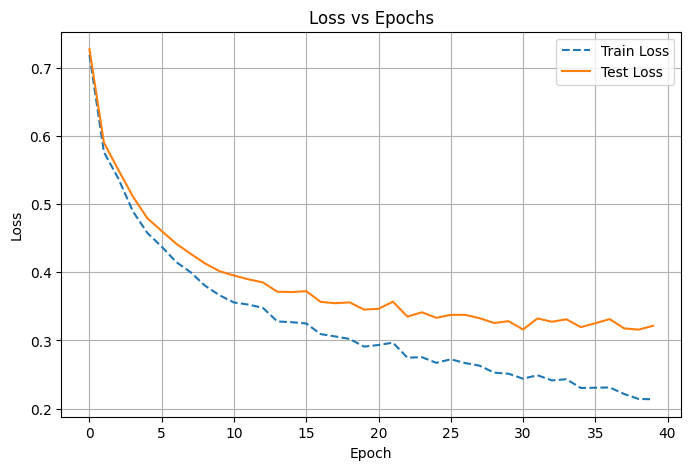

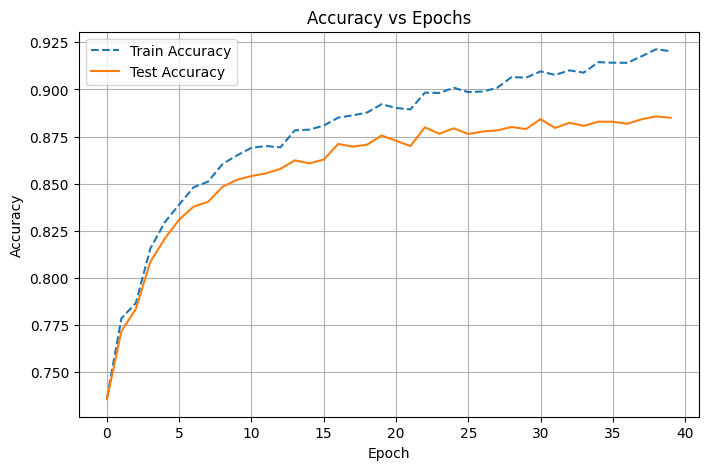

In [89]:
# -----------------------------
# 1. CURVA DE LOSS
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_avg_loss_exp3, label="Train Loss", linestyle="--")
plt.plot(list_test_avg_loss_exp3, label="Test Loss", linestyle="-")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2. CURVA DE ACCURACY
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(list_train_accuracy_exp3, label="Train Accuracy", linestyle="--")
plt.plot(list_test_accuracy_exp3, label="Test Accuracy", linestyle="-")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

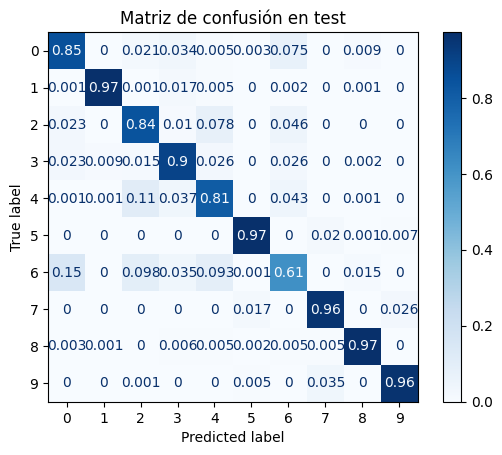

In [91]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_exp3)
disp.plot(cmap='Blues')
plt.title("Matriz de confusión en test")
plt.show()

<Figure size 700x600 with 0 Axes>

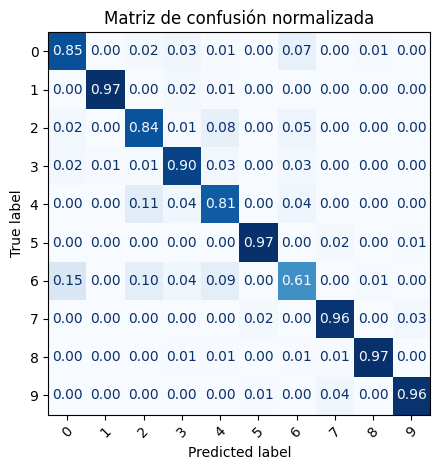

In [94]:
plt.figure(figsize=(7,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_exp3)
disp.plot(cmap='Blues', values_format=".2f", colorbar=False)
plt.xticks(rotation=45)
plt.title("Matriz de confusión normalizada")
plt.tight_layout()
plt.show()

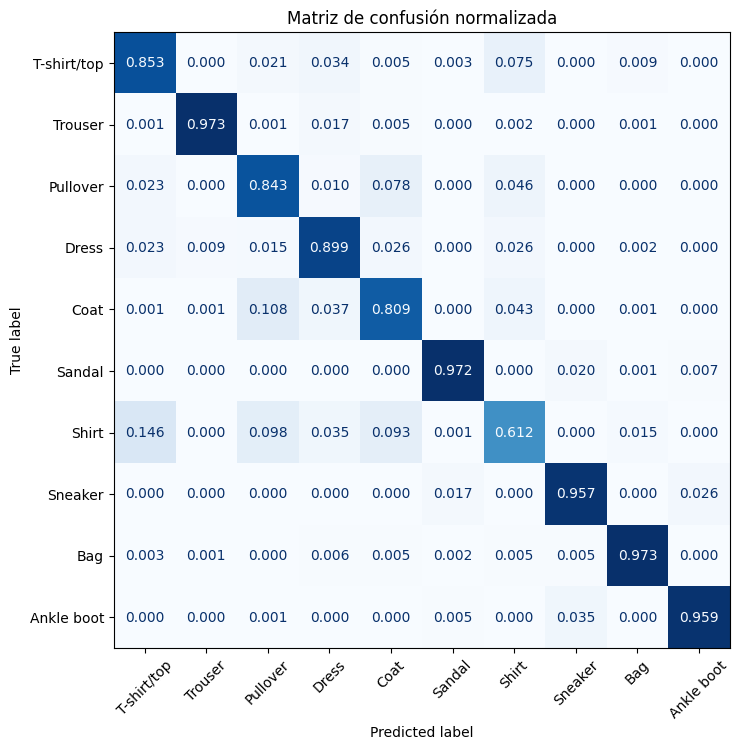

In [112]:
fashion_labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_exp3,
                              display_labels=fashion_labels)

disp.plot(cmap='Blues', values_format=".3f", colorbar=False, ax=ax)
plt.xticks(rotation=45)
plt.title("Matriz de confusión normalizada")
#plt.tight_layout()
plt.show()

In [113]:
list_train_avg_loss_exp3[-1], list_test_avg_loss_exp3[-1]

(0.21388625281102333, 0.3216149943470955)

In [114]:
list_train_accuracy_exp3[-1], list_test_accuracy_exp3[-1]

(0.9202666666666667, 0.885)

In [ ]:
(0.91555, 0.8842)

(0.2284101951032256, 0.3277376963868737)

## Experimento 0

In [131]:
lr = 0.0001
conv_classifier_6 = Classifier_conv6(AutoEncoder_pre_trained, 784, 0.2)
optimizer = torch.optim.Adam(conv_classifier_6.classifier.parameters(), lr=lr)
conv_classifier_6.to(device)


epochs = 40
list_train_avg_loss_exp0 = []
list_test_avg_loss_exp0 = []
list_train_accuracy_exp0 = []
list_test_accuracy_exp0 = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc, train_acc_inc = train_loop(train_loader_classifier,
                                                 conv_classifier_6,
                                                 loss_fn,
                                                 optimizer)
    train_avg_loss_exp0, train_acc_exp0, cm_exp0 = test_loop(train_loader_classifier,
                                        conv_classifier_6,
                                        loss_fn)

    test_avg_loss_exp0, test_acc_exp0, cm_exp0 = test_loop(test_loader_classifier,
                                        conv_classifier_6,
                                        loss_fn)

    list_train_avg_loss_exp0.append(train_avg_loss_exp0)
    list_test_avg_loss_exp0.append(test_avg_loss_exp0)

    list_train_accuracy_exp0.append(train_acc_exp0)
    list_test_accuracy_exp0.append(test_acc_exp0)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26


In [132]:
list_train_accuracy_exp0[-1], list_test_accuracy_exp0[-1]

(0.9639333333333333, 0.907)

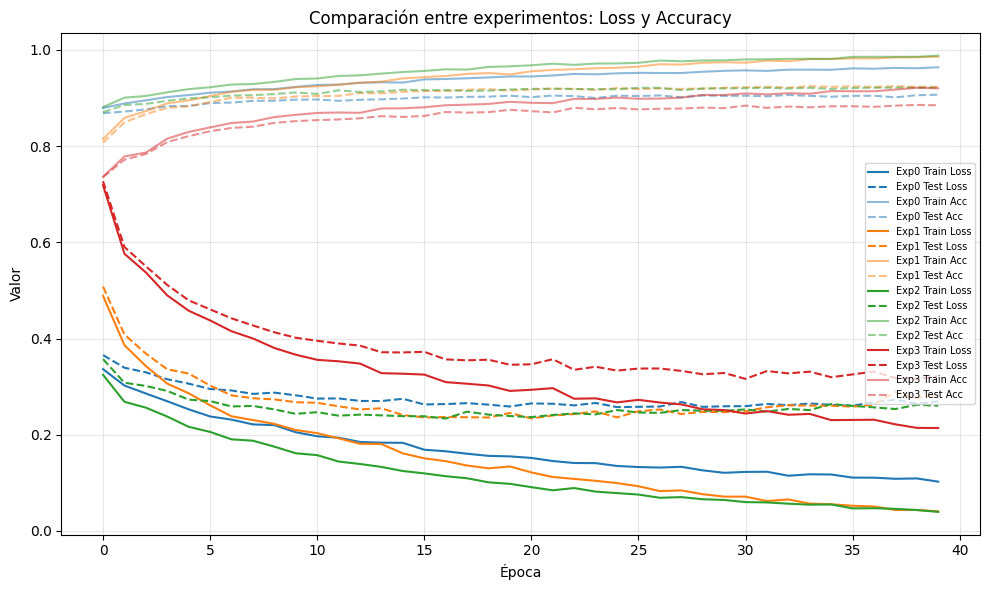

In [143]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

epochs = range(len(list_train_avg_loss_exp1))

# Colores por experimento
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

# ===== EXPERIMENTO 0 =====
plt.plot(epochs, list_train_avg_loss_exp0, color=colors[0], linestyle='-', label='Exp0 Train Loss')
plt.plot(epochs, list_test_avg_loss_exp0, color=colors[0], linestyle='--', label='Exp0 Test Loss')
plt.plot(epochs, list_train_accuracy_exp0, color=colors[0], linestyle='-', alpha=0.5, label='Exp0 Train Acc')
plt.plot(epochs, list_test_accuracy_exp0, color=colors[0], linestyle='--', alpha=0.5, label='Exp0 Test Acc')

# ===== EXPERIMENTO 1 =====
plt.plot(epochs, list_train_avg_loss_exp1, color=colors[1], linestyle='-', label='Exp1 Train Loss')
plt.plot(epochs, list_test_avg_loss_exp1, color=colors[1], linestyle='--', label='Exp1 Test Loss')
plt.plot(epochs, list_train_accuracy_exp1, color=colors[1], linestyle='-', alpha=0.5, label='Exp1 Train Acc')
plt.plot(epochs, list_test_accuracy_exp1, color=colors[1], linestyle='--', alpha=0.5, label='Exp1 Test Acc')

# ===== EXPERIMENTO 2 =====
plt.plot(epochs, list_train_avg_loss_exp2, color=colors[2], linestyle='-', label='Exp2 Train Loss')
plt.plot(epochs, list_test_avg_loss_exp2, color=colors[2], linestyle='--', label='Exp2 Test Loss')
plt.plot(epochs, list_train_accuracy_exp2, color=colors[2], linestyle='-', alpha=0.5, label='Exp2 Train Acc')
plt.plot(epochs, list_test_accuracy_exp2, color=colors[2], linestyle='--', alpha=0.5, label='Exp2 Test Acc')

# ===== EXPERIMENTO 3 =====
plt.plot(epochs, list_train_avg_loss_exp3, color=colors[3], linestyle='-', label='Exp3 Train Loss')
plt.plot(epochs, list_test_avg_loss_exp3, color=colors[3], linestyle='--', label='Exp3 Test Loss')
plt.plot(epochs, list_train_accuracy_exp3, color=colors[3], linestyle='-', alpha=0.5, label='Exp3 Train Acc')
plt.plot(epochs, list_test_accuracy_exp3, color=colors[3], linestyle='--', alpha=0.5, label='Exp3 Test Acc')

# ===== ESTÉTICA =====
plt.xlabel("Época")
plt.ylabel("Valor")
plt.title("Comparación entre experimentos: Loss y Accuracy")
plt.grid(alpha=0.3)
plt.legend(fontsize=7, loc='best')
plt.tight_layout()

plt.show()

## Ejercicio 5) Entrenando el modelo

**1)** Implemente, en una función, un loop de entrenamiento que recorra los batchs (lotes).

**2)** Implemente, en una función, un loop de prueba o validación que recorra los batchs.

**3)** Inicialize dos `DataLoader`s llamados `train_loader` y `valid_loader` que estén definidos sobre  el `train_set` (conjunto de entranmiento) y el `valid_set` (conjunto de prueba) de Fashion-MNIST, respectivamente, y que usen batchs de 100 ejemplos.

**4)** Cree una función de pérdida usando el **Error Cuadrático Medio**.

**5)** Cree un optimizador con un learning rate igual a $10^{-3}$.
Pruebe con **ADAM**.

**6)** Cree una instancia del modelo con dropout $p=0.2$.

**7)** Especifique en que dispositivo (`device`) va a trabajar: en una **CPU** o en una **GPU**.

**8)** Implemente un loop que itere sobre épocas de entrenamiento y validación, y que guarde en listas correspondientes los siguientes valores del **ECM**:
*  promedios (incorrectos) sobre el conjunto de entrenamiento, calculado **durante** el proceso de entrenamiento sobre la época.
*  promedios (correctos) sobre el conjunto de entrenamiento, calculados **posteriormente** al proceso de entrenamiento sobre la época.
*  promedios (correctos) sobre el conjunto de validación, calculados **posteriormente** al proceso de entrenamiento sobre la época.

**IMPORTANTE:** No olvide copiar los batchs al dispositivo de trabajo.

**9)** Entrene y valide el modelo.

**10)** Use las listas del inciso **8)** para graficar en función de las **épocas de entrenamiento** el **ECM** de **entrenamiento** y **validación**, respectivamente.
Discuta y comente, cual es el número óptimo de épocas de entrenamiento?

**11)** Grafique, comparativamente, algunas de las imagenes a predecir vs las imagenes predichas por el modelo entrenado.

**12)** Repita para otras elecciones de los hiperparámetros tales como, el optimizador (podría ser el **SGD**), el **learning-rate**, el tamaño de los **batchs**, el **dropout**, **capas convolucionales** y **convolucionales traspuestas** de otros tamaños.
En particular, pruebe eliminando, adecuadamente, la **capa lineal**.
Que valores de estos hiperparámetros considera los más convenientes? Porqué?

In [ ]:
# 5.1)